# Domain-gap analysis: how different are our local chest CTs from public ones?

**Question.** CT-CLIP scores our 7 local scans worse than public CT-RATE scans. Is that because our scans are *different* (scanner, kernel, protocol, patients), or is it just the model? This notebook measures the difference directly, **without using any labels**, in three complementary ways:

| Layer | What is compared | Why it is useful |
|---|---|---|
| **A. Image statistics** | HU calibration (air / fat / soft-tissue peaks), lung density, noise, sharpness, body size, z-coverage | Physically interpretable: says *what* differs |
| **B. Learned features** | Embeddings from three different encoders: **CT-CLIP** (the model we are testing), **DALE-CT-0** (2D ViT-L, self-supervised on CT-RATE) and **CT-FM** (3D SegResNet, self-supervised on 148k CT scans, *not* trained on CT-RATE) | Says *how far* the scans are in the space the models actually use |
| **C. Link to performance** | Does "novelty" predict CT-CLIP's error on public scans? | Tells whether a gap would actually matter |

**Reference cohorts** (downloaded automatically, cached): **CT-RATE** validation scans (Philips / Siemens; stratified by scanner and kernel, plus *second reconstructions of the same scan* for a kernel-effect yardstick) and **LIDC-IDRI** from TCIA (GE / Siemens / Philips / **Toshiba**, the vendor of our scans).

### Why the statistics look like this (n = 7 local scans)
* A classic **FID needs a covariance matrix** of the features; with 7 samples it has rank ≤ 6, so FID in 512 dimensions is not defined. We reduce to a few PCA dimensions and never trust a raw number on its own.
* Instead every statistic is compared with a **size-matched null**: how large would it be for a *random set of 7 public scans* against the rest of the public reference? That removes small-sample bias and gives an honest p-value / percentile.
* Every gap is put on a **yardstick**: the same statistic for (i) a *vendor* the reference has never seen (leave-one-vendor-out), (ii) the *same scan reconstructed with a different kernel*, and (iii) ordinary patient-to-patient variation. "Local is 1.4x the vendor gap" means more than "p = 0.01".
* Effect sizes (Cliff's delta, robust z) with bootstrap intervals are reported next to p-values; p-values with n = 7 are coarse.
* Optional **controls** degrade public scans by known amounts (noise, blur, HU shift, thick slices) to show how large a change each method can detect, and where our scans fall on that scale.

### Setup
* Local DICOMs: same Drive folder as the CT-CLIP notebook (`raw/NHRD - CT Scan`). Edit the paths in section 1 if yours differ.
* Hugging Face token (secret `HF_TOKEN` on Colab, or `HF_TOKEN` env var) with access to the gated `ibrahimhamamci/CT-RATE` dataset and CT-CLIP weights. DALE-CT-0 and CT-FM are public. TCIA needs no login.
* GPU runtime recommended (CPU works but is slow). Everything computed is cached under `domain_gap_outputs/cache`, so re-runs are quick.
* Set `DRY_RUN_RANDOM_WEIGHTS = True` to test the plumbing with random weights (results meaningless).

**Licences:** DALE-CT weights CC-BY-NC-SA-4.0, CT-FM Apache-2.0, LIDC-IDRI CC BY 3.0 (TCIA), CT-RATE CC-BY-NC-SA-4.0. Research use only.

## 1. Configuration

In [2]:
import os, sys, re, gc, io, json, time, glob, shutil, zipfile, platform, subprocess, warnings, hashlib, datetime as dt
from pathlib import Path
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
def _env(name, default=None, cast=str):
    v = os.environ.get(name)
    return default if v in (None, "") else cast(v)

# ------------------------------ USER SETTINGS ------------------------------
EXTRACTORS = ["ctclip", "dale", "ctfm"]     # subset allowed, e.g. ["ctclip", "ctfm"]
MAX_LOCAL = _env("CTDG_MAX_LOCAL", None, int)          # None = all local cases
N_CTRATE = _env("CTDG_N_CTRATE", 48, int)              # CT-RATE validation scans (unique patients), stratified by vendor x kernel
N_CTRATE_PAIRS = _env("CTDG_N_PAIRS", 12, int)         # of those, how many also get their SECOND reconstruction (kernel-effect yardstick)
CTRATE_SEED = 0
RUN_LIDC = _env("CTDG_RUN_LIDC", "1") == "1"           # second public source (TCIA), includes Toshiba
LIDC_PER_VENDOR = {"TOSHIBA": 10, "GE MEDICAL SYSTEMS": 8, "SIEMENS": 8, "Philips": 8}
LIDC_MIN_IMAGES = {"TOSHIBA": 100, "default": 200}     # thin-slice series only (>= ~1.5 mm); Toshiba in LIDC is almost all 2.5-3 mm
LIDC_SEED = 0
EXTRA_DICOM_DIRS = _env("CTDG_EXTRA_DIRS", None, lambda s: [x for x in s.split(";") if x])   # optional: folders holding one extra DICOM series each
CTRATE_VOLUMES = _env("CTDG_CTRATE_VOLUMES", None, lambda s: [x for x in s.split(",") if x])  # or explicit VolumeNames (skips the stratified selection)
CTRATE_MAX_VOXELS = 512 * 512 * 700                    # RAM guard (12 GB Colab)
DEVICE = "auto"                                        # "auto" -> cuda if available
DALE_MODEL = "Kentucky-Open-Science/DALE-CT-0"         # pure self-supervised; also works: DALE-CT-1S-v2, DALE-CT-2S
DALE_SLAB_MM = 12.0                                    # one slice per 12 mm slab (as in the DALE-CT paper)
DALE_ARRANGEMENT = "ctrate"                            # "ctrate" = slices as stored in CT-RATE arrays (assumed training arrangement) or "upright"
DALE_MAX_SLICES = _env("CTDG_DALE_MAX_SLICES", None, int)   # cap (only for quick tests)
CTFM_SPACING_MM = 3.0                                  # working resolution for the 3D encoder (memory); 1.5 gives finer features but ~8x memory
KNN_K = 3                                              # novelty = mean distance to the k nearest reference scans
PCA_DIMS = 10                                          # dimensions of the comparison space (fit on the reference only)
N_NULL = _env("CTDG_N_NULL", 2000, int)                # random size-matched subsets for the null distributions
N_BOOT = 1000
RUN_CONTROLS = _env("CTDG_RUN_CONTROLS", "auto")       # "auto" = only with a GPU; "1"/"0" to force
N_CONTROL_SCANS = 6
DELETE_RAW_AFTER_EMBED = True                          # public volumes are deleted after their features are cached (saves disk)
DRY_RUN_RANDOM_WEIGHTS = _env("CTDG_DRY_RUN", "0") == "1"
HF_TOKEN = os.environ.get("HF_TOKEN")
# ---------------------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/NHRD - Local Sample"
    WORK_DIR = "/content/domain_gap_work"
    if not HF_TOKEN:
        try:
            from google.colab import userdata
            HF_TOKEN = userdata.get("HF_TOKEN")
        except Exception:
            pass
else:
    BASE_DIR = _env("CTDG_BASE_DIR", os.path.expanduser("~/NHRD - Local Sample"))
    WORK_DIR = _env("CTDG_WORK_DIR", os.path.expanduser("~/domain_gap_work"))

DICOM_ROOT = _env("CTDG_DICOM_ROOT", f"{BASE_DIR}/raw/NHRD - CT Scan")
LABELS_CSV = _env("CTDG_LABELS_CSV", f"{BASE_DIR}/outputs/Labels/labels.csv")      # optional: only used for the performance link (section 9)
OUTPUT_DIR = Path(_env("CTDG_OUTPUT_DIR", f"{BASE_DIR}/domain_gap_outputs")) / ("dryrun" if DRY_RUN_RANDOM_WEIGHTS else "")
CACHE_DIR = OUTPUT_DIR / "cache"
RAW_DIR = Path(WORK_DIR) / "raw"                       # downloaded public volumes (local disk)
WEIGHTS_DIR = Path(WORK_DIR) / "weights"
for d in (OUTPUT_DIR / "figures", CACHE_DIR, RAW_DIR, WEIGHTS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("Colab:", IN_COLAB, "| dry run:", DRY_RUN_RANDOM_WEIGHTS)
for k in ("BASE_DIR", "DICOM_ROOT", "LABELS_CSV", "OUTPUT_DIR", "WORK_DIR"):
    print(f"{k:11s}", globals()[k])

Mounted at /content/drive
Colab: True | dry run: False
BASE_DIR    /content/drive/MyDrive/NHRD - Local Sample
DICOM_ROOT  /content/drive/MyDrive/NHRD - Local Sample/raw/NHRD - CT Scan
LABELS_CSV  /content/drive/MyDrive/NHRD - Local Sample/outputs/Labels/labels.csv
OUTPUT_DIR  /content/drive/MyDrive/NHRD - Local Sample/domain_gap_outputs
WORK_DIR    /content/domain_gap_work


## 2. Environment

In [3]:
def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

try:
    import torch
except ImportError:
    pip_install("torch"); import torch
try:
    import cv2  # noqa: F401
except ImportError:
    pip_install("opencv-python-headless")
pip_install("pydicom>=3.0", "nibabel", "einops>=0.6", "vector-quantize-pytorch==1.1.2", "beartype", "ema-pytorch", "accelerate", "openpyxl", "sentencepiece",
            "huggingface_hub", "transformers", "timm", "safetensors", "scikit-learn", "scipy", "monai", "requests", "psutil", "pandas", "matplotlib")
try:
    import umap  # noqa: F401
except ImportError:
    try:
        pip_install("umap-learn")
    except Exception:
        print("umap-learn not installed: t-SNE will be used for the 2-D maps instead")

def sh(*cmd):
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(f"{' '.join(map(str, cmd))} failed: {r.stderr}")
    return r.stdout.strip()

# --- CT-CLIP code (needed for the CT-CLIP encoder). The upstream code hard-codes torch.device('cuda'); we make it follow CTCLIP_DEVICE.
REPO_URL, REPO_COMMIT = "https://github.com/ibrahimethemhamamci/CT-CLIP.git", "a2a155c601987820433c01db69b64d701d3d229d"
REPO_DIR = Path(WORK_DIR) / "CT-CLIP"
if not REPO_DIR.exists():
    sh("git", "clone", "--depth", "1", REPO_URL, REPO_DIR)
    try:
        sh("git", "-C", REPO_DIR, "fetch", "--depth", "1", "origin", REPO_COMMIT)
        sh("git", "-C", REPO_DIR, "checkout", "-q", "FETCH_HEAD")
    except RuntimeError:
        print("Pinned commit could not be fetched - using the latest main branch.")
CUDA_PATTERN = re.compile(r"torch\.device\('cuda'\)")
CUDA_REPLACEMENT = "torch.device(__import__('os').environ.get('CTCLIP_DEVICE', 'cuda' if torch.cuda.is_available() else 'cpu'))"
for rel in ("transformer_maskgit/transformer_maskgit/attention.py", "transformer_maskgit/transformer_maskgit/ctvit.py"):
    p = REPO_DIR / rel
    s_, n_ = CUDA_PATTERN.subn(CUDA_REPLACEMENT, p.read_text(encoding="utf-8"))
    if n_:
        p.write_text(s_, encoding="utf-8")
sys.path[:0] = [str(REPO_DIR / "transformer_maskgit"), str(REPO_DIR / "CT_CLIP")]

import numpy as np, pandas as pd, psutil, requests
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import pydicom
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")

DEV = ("cuda" if torch.cuda.is_available() else "cpu") if DEVICE == "auto" else DEVICE
os.environ["CTCLIP_DEVICE"] = DEV
print("torch", torch.__version__, "| device:", DEV, "| GPU:", torch.cuda.get_device_name(0) if DEV == "cuda" else "-", "| threads:", torch.get_num_threads())
if RUN_CONTROLS == "auto":
    RUN_CONTROLS = "1" if DEV == "cuda" else "0"
RUN_CONTROLS = RUN_CONTROLS == "1"

torch 2.11.0+cu128 | device: cuda | GPU: Tesla T4 | threads: 1


## 3. Reading CT volumes into one common arrangement
Every volume (local DICOM, public DICOM, CT-RATE NIfTI) is converted to the **CT-RATE array arrangement** `(z ascending toward the head, axis toward the patient's LEFT, axis toward POSTERIOR)`, the arrangement CT-CLIP was trained on (verified in the CT-CLIP notebook: the model's height axis is the patient-left axis). From that one tensor every extractor gets what it expects (DALE-CT: 2-D slices; CT-FM: SPL orientation), so the cohorts can never be treated differently by accident.

In [4]:
TARGET_SPACING = (1.5, 0.75, 0.75)      # (z, height, width) mm
TARGET_SHAPE = (240, 480, 480)          # voxels

def list_dicom_headers(case_dir):
    """Read headers of every DICOM in a folder tree (non-DICOM files such as LICENSE are skipped)."""
    out = []
    for f in sorted(Path(case_dir).rglob("*")):
        if not f.is_file() or f.suffix.lower() in (".txt", ".md", ".json", ".csv", ".xml", ".zip"):
            continue
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=True)
        except Exception:
            continue
        if getattr(ds, "Modality", None) == "CT" and hasattr(ds, "ImagePositionPatient") and hasattr(ds, "Rows"):
            out.append((f, ds))
    return out

def read_dicom_series(case_dir):
    """Largest axial CT series in a folder -> (vol (Z, rows, cols) float32 HU sorted by patient z ascending, spacing (z, row, col), iop, meta)."""
    items = list_dicom_headers(case_dir)
    if not items:
        raise RuntimeError(f"no CT slices in {case_dir}")
    series = {}
    for f, ds in items:
        series.setdefault((str(ds.SeriesInstanceUID), int(ds.Rows), int(ds.Columns)), []).append((f, ds))
    key = max(series, key=lambda k: len(series[k]))
    sel = series[key]
    iop = np.array(sel[0][1].ImageOrientationPatient, float)
    normal = np.cross(iop[:3], iop[3:])
    ax = int(np.argmax(np.abs(normal)))
    pos = np.array([float(ds.ImagePositionPatient[ax]) for _, ds in sel])
    order = np.argsort(pos)
    pos_sorted = pos[order]
    keep = np.concatenate([[True], np.diff(pos_sorted) > 1e-3])              # drop duplicated positions
    order = order[keep]; pos_sorted = pos_sorted[keep]
    steps = np.diff(pos_sorted)
    d0 = sel[0][1]
    z_sp = float(np.median(steps)) if len(steps) and np.median(steps) > 0 else float(getattr(d0, "SliceThickness", 1.0))
    row_sp, col_sp = (float(v) for v in d0.PixelSpacing)
    vol = np.empty((len(order), key[1], key[2]), np.float32)
    for i, k in enumerate(order):
        d = pydicom.dcmread(str(sel[k][0]))
        vol[i] = d.pixel_array.astype(np.float32) * float(getattr(d, "RescaleSlope", 1)) + float(getattr(d, "RescaleIntercept", 0))
    g = lambda name, default=None: getattr(d0, name, default)
    year = str(g("StudyDate", ""))[:4]
    meta = dict(vendor=str(g("Manufacturer", "?")).strip(), model=str(g("ManufacturerModelName", "?")).strip(), kernel=str(g("ConvolutionKernel", "?")).strip("[]' "),
                slice_thickness=float(g("SliceThickness", np.nan) or np.nan), z_spacing=z_sp, xy_spacing=row_sp, kvp=float(g("KVP", np.nan) or np.nan),
                tube_current=float(g("XRayTubeCurrent", np.nan) or np.nan), fov=float(g("ReconstructionDiameter", np.nan) or np.nan), position=str(g("PatientPosition", "?")),
                contrast=("yes" if str(g("ContrastBolusAgent", "")).strip() and "W/O" not in str(g("ContrastBolusAgent", "")).upper() else "no/unknown"),
                n_slices=len(order), rows=key[1], cols=key[2], study_year=int(year) if year.isdigit() else np.nan, iop=[round(float(v), 4) for v in iop],
                z_uniform=bool(len(steps) == 0 or np.ptp(steps) < 0.1 * z_sp), transfer_syntax=d0.file_meta.TransferSyntaxUID.name)
    return vol, (z_sp, row_sp, col_sp), iop, meta

def to_ctrate_arrangement(vol_zrc, spacing_zrc, iop):
    """(Z, rows, cols) DICOM stack -> (Z, axis toward patient LEFT, axis toward POSTERIOR), the CT-RATE array arrangement. Verified for all
    8 combinations of row/column direction and sign in the CT-CLIP notebook (bit-identical result for every convention)."""
    z_sp, row_sp, col_sp = spacing_zrc
    dc, dr = np.asarray(iop[:3], float), np.asarray(iop[3:], float)     # LPS direction of increasing column / row index
    if abs(dc[0]) >= abs(dr[0]):                                          # standard axial: columns run left-right, rows anterior-posterior
        out, sp, flip_h, flip_w = vol_zrc.transpose(0, 2, 1), (z_sp, col_sp, row_sp), dc[0] < 0, dr[1] < 0
    else:
        out, sp, flip_h, flip_w = vol_zrc, (z_sp, row_sp, col_sp), dr[0] < 0, dc[1] < 0
    if flip_h:
        out = out[:, ::-1]
    if flip_w:
        out = out[:, :, ::-1]
    return np.ascontiguousarray(out), sp

def _crop_pad_axis(t, dim, target):
    n = t.shape[dim]
    start = max((n - target) // 2, 0)
    t = t.narrow(dim, start, min(start + target, n) - start)
    before = (target - t.shape[dim]) // 2
    return t, (before, target - t.shape[dim] - before)

def preprocess_volume(vol_B, spacing_B):
    """Official CT-CLIP preprocessing (data_inference_nii.py) of an already CT-RATE-arranged HU volume -> float32 (1, 240, 480, 480), air = -1."""
    v = torch.from_numpy(np.clip(vol_B, -1000, 1000))[None, None]
    new_shape = [int(n * cur / tgt) for n, cur, tgt in zip(v.shape[2:], spacing_B, TARGET_SPACING)]
    v = F.interpolate(v, size=new_shape, mode="trilinear", align_corners=False)[0, 0] / 1000.0
    pads = []
    for dim, tgt in enumerate(TARGET_SHAPE):
        v, p = _crop_pad_axis(v, dim, tgt)
        pads.append(p)
    v = F.pad(v, (*pads[2], *pads[1], *pads[0]), value=-1.0)
    assert tuple(v.shape) == TARGET_SHAPE, v.shape
    return v.unsqueeze(0).contiguous()

## 4. Cohorts
**local** = our scans; **ctrate** = CT-RATE validation scans (`valid_fixed`); **lidc** = LIDC-IDRI from TCIA; **extra** = optional folders you add yourself.
CT-RATE selection is *stratified by vendor x kernel* (round-robin over strata, so rare kernels are represented) and one volume per patient; the second reconstruction of some acquisitions is downloaded as well, to measure how much a kernel change alone moves the features.

In [5]:
def case_key(x):
    m = re.match(r"\s*(\d+)", str(x)); return int(m.group(1)) if m else str(x)

ITEMS = []      # one dict per volume: cohort, id, loader info, group (patient), pair_id, meta (filled while loading)

# ---------------- local
local_dirs = [d for d in sorted(Path(DICOM_ROOT).iterdir()) if d.is_dir() and any(d.rglob("*.dcm"))] if Path(DICOM_ROOT).exists() else []
if MAX_LOCAL:
    local_dirs = local_dirs[:MAX_LOCAL]
for d in local_dirs:
    ITEMS.append(dict(cohort="local", id=f"local_{case_key(d.name)}", path=str(d), group=f"local_{case_key(d.name)}", pair_id=None, primary=True, control=False))
print(f"local scans: {len(local_dirs)}" + ("" if local_dirs else f"   <-- none found under {DICOM_ROOT}"))

# ---------------- CT-RATE
CT_REPO = "ibrahimhamamci/CT-RATE"
CTRATE_DIR = Path(WORK_DIR) / "ctrate_meta"
CTRATE_DIR.mkdir(parents=True, exist_ok=True)
_num = lambda s: (re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(s)) or ["nan"])[0]

def hf_fetch(rel, local_dir):
    dst = Path(local_dir) / rel
    if dst.exists() and dst.stat().st_size > 0:
        return dst
    from huggingface_hub import hf_hub_download
    return Path(hf_hub_download(repo_id=CT_REPO, repo_type="dataset", filename=rel, token=HF_TOKEN or None, local_dir=str(local_dir)))

def ctrate_rel_path(name):
    m = re.match(r"valid_(\d+)_([a-z]+)_(\d+)\.nii\.gz$", name)
    return f"dataset/valid_fixed/valid_{m[1]}/valid_{m[1]}_{m[2]}/{name}"

def vendor_group(s):
    s = str(s).lower()
    return "Philips" if "philips" in s else "Siemens" if "siemens" in s else "PNMS" if "pnms" in s else "Toshiba" if ("toshiba" in s or "canon" in s) else "GE" if "ge " in s or s.startswith("ge") else str(s)

def kernel_family(k):
    k = str(k).strip("[]' ").split("'")[0].split(",")[0].strip()
    return k or "?"

def select_ctrate(meta, labels_idx, nochest, n_total, n_pairs, seed, max_voxels):
    """Stratified (vendor x kernel) round-robin selection of unique patients + a subset of sibling reconstructions. Returns (primary_names, sibling_map)."""
    M = meta.copy()
    M["xy"] = M.XYSpacing.map(lambda s: float(_num(s))); M["z"] = pd.to_numeric(M.ZSpacing, errors="coerce")
    M["voxels"] = M.Rows * M.Columns * M.NumberofSlices; M["zext"] = M.NumberofSlices * M.z
    M["patient"] = M.index.str.extract(r"valid_(\d+)_", expand=False); M["acq"] = M.index.str.extract(r"valid_(\d+_[a-z]+)_", expand=False)
    M["vendor"] = M.Manufacturer.map(vendor_group); M["kfam"] = M.ConvolutionKernel.map(kernel_family)
    ok = M[~M.index.str.replace(".nii.gz", "", regex=False).isin(nochest) & M.z.notna() & M.xy.notna() & (M.voxels <= max_voxels) & (M.zext >= 150) & M.index.isin(labels_idx)]
    rng = np.random.default_rng(seed)
    pool = ok.sample(frac=1.0, random_state=seed).sort_values("voxels", kind="stable").groupby("patient").head(1)       # one (smaller) recon per patient
    strata = {k: list(g.index) for k, g in pool.groupby(["vendor", "kfam"])}
    for k in strata:
        rng.shuffle(strata[k])
    order = sorted(strata, key=lambda k: -len(strata[k]))
    chosen = []
    while len(chosen) < n_total and any(strata.values()):
        for k in order:
            if strata[k] and len(chosen) < n_total:
                chosen.append(strata[k].pop())
    # siblings: other reconstructions of the same acquisition
    sib = {}
    cand = [n for n in chosen if len(ok[(ok.acq == M.loc[n, "acq"]) & (ok.index != n)]) > 0]
    rng.shuffle(cand)
    for n in cand[:n_pairs]:
        others = ok[(ok.acq == M.loc[n, "acq"]) & (ok.index != n)]
        sib[n] = others.sort_values("voxels").index[0]
    return sorted(chosen), sib, M

CT_META = None
if CTRATE_VOLUMES or N_CTRATE > 0:
    try:
        ct_meta = pd.read_csv(hf_fetch("dataset/metadata/validation_metadata.csv", CTRATE_DIR)).set_index("VolumeName")
        ct_labels = pd.read_csv(hf_fetch("dataset/multi_abnormality_labels/valid_predicted_labels.csv", CTRATE_DIR)).set_index("VolumeName")
        ct_nochest = set(re.findall(r"(valid_\d+_[a-z]+_\d+)\.nii\.gz", hf_fetch("dataset/metadata/no_chest_valid.txt", CTRATE_DIR).read_text()))
        if CTRATE_VOLUMES:
            prim = [n for n in CTRATE_VOLUMES if n in ct_meta.index]; sibs = {}
            CT_META = ct_meta.copy(); CT_META["vendor"] = CT_META.Manufacturer.map(vendor_group); CT_META["kfam"] = CT_META.ConvolutionKernel.map(kernel_family)
        else:
            prim, sibs, CT_META = select_ctrate(ct_meta, set(ct_labels.index), ct_nochest, N_CTRATE, N_CTRATE_PAIRS, CTRATE_SEED, CTRATE_MAX_VOXELS)
        for n in prim:
            pid = re.match(r"valid_(\d+)_", n)[1]
            ITEMS.append(dict(cohort="ctrate", id=n.replace(".nii.gz", ""), name=n, group=f"ctrate_{pid}", pair_id=(re.match(r"(valid_\d+_[a-z]+)_", n)[1] if n in sibs else None), primary=True, control=False))
        for n, s in sibs.items():
            ITEMS.append(dict(cohort="ctrate", id=s.replace(".nii.gz", ""), name=s, group=f"ctrate_{re.match(r'valid_(\d+)_', s)[1]}", pair_id=re.match(r"(valid_\d+_[a-z]+)_", s)[1], primary=False, control=False))
        sel = CT_META.loc[prim]
        print(f"CT-RATE: {len(prim)} unique patients (+{len(sibs)} sibling reconstructions)")
        display(pd.crosstab(sel.vendor, sel.kfam))
    except Exception as e:
        print("CT-RATE could not be set up:", repr(e)[:300], "\n-> check HF_TOKEN and that you accepted the dataset terms. CT-RATE is skipped.")

# ---------------- LIDC-IDRI (TCIA public API, no login)
TCIA = "https://services.cancerimagingarchive.net/nbia-api/services/v1"
def _get(url, **kw):
    for attempt in range(4):
        try:
            r = requests.get(url, timeout=kw.pop("timeout", 180), **kw)
            r.raise_for_status()
            return r
        except Exception as e:
            if attempt == 3:
                raise
            time.sleep(3 * (attempt + 1))

def select_lidc(per_vendor, min_images, seed):
    rows = []
    for vendor in per_vendor:
        rows += _get(f"{TCIA}/getSeries", params={"Collection": "LIDC-IDRI", "Modality": "CT", "Manufacturer": vendor, "format": "json"}).json()
    D = pd.DataFrame(rows)
    D = D[D.ImageCount >= D.Manufacturer.map(lambda v: min_images.get(v, min_images["default"]))]
    pick = []
    for vendor, n in per_vendor.items():
        g = D[D.Manufacturer == vendor].drop_duplicates("PatientID")
        pick.append(g.sample(n=min(n, len(g)), random_state=seed))
    return pd.concat(pick).reset_index(drop=True)

if RUN_LIDC:
    try:
        LIDC_SEL = select_lidc(LIDC_PER_VENDOR, LIDC_MIN_IMAGES, LIDC_SEED)
        for r in LIDC_SEL.itertuples():
            ITEMS.append(dict(cohort="lidc", id=f"lidc_{r.PatientID}", uid=r.SeriesInstanceUID, group=f"lidc_{r.PatientID}", pair_id=None, primary=True, control=False,
                              listed_vendor=r.Manufacturer, listed_mb=r.FileSize / 1e6))
        print(f"LIDC-IDRI: {len(LIDC_SEL)} series | listed size {LIDC_SEL.FileSize.sum() / 1e9:.1f} GB")
        display(LIDC_SEL.groupby("Manufacturer").agg(n=("ImageCount", "size"), median_images=("ImageCount", "median")))
    except Exception as e:
        print("LIDC-IDRI could not be set up (TCIA unreachable?):", repr(e)[:300])
for d in (EXTRA_DICOM_DIRS or []):
    ITEMS.append(dict(cohort="extra", id=f"extra_{Path(d).name}", path=str(d), group=f"extra_{Path(d).name}", pair_id=None, primary=True, control=False))
print("total volumes to process:", len(ITEMS), "|", pd.Series([i["cohort"] for i in ITEMS]).value_counts().to_dict())

local scans: 7


validation_metadata.csv:   0%|          | 0.00/948k [00:00<?, ?B/s]

valid_predicted_labels.csv:   0%|          | 0.00/174k [00:00<?, ?B/s]

no_chest_valid.txt:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

CT-RATE: 48 unique patients (+12 sibling reconstructions)


kfam,A,B,Bl56f,Bl57d,Br36d,Br40f,Br44f,Br60f,EA,L,SA,SB
vendor,,,,,,,,,,,,
PNMS,0,0,0,0,0,0,0,0,5,0,4,1
Philips,5,5,0,0,0,0,0,0,0,1,0,0
Siemens,0,0,5,4,4,5,4,5,0,0,0,0


LIDC-IDRI: 34 series | listed size 4.6 GB


,n,median_images
Manufacturer,,
GE MEDICAL SYSTEMS,8,271.0
Philips,8,292.5
SIEMENS,8,326.5
TOSHIBA,10,117.0


total volumes to process: 101 | {'ctrate': 60, 'lidc': 34, 'local': 7}


In [6]:
def read_ctrate_volume(name, raw_dir):
    """CT-RATE NIfTI -> (vol (k, i, j) = (Z, LEFT axis, POSTERIOR axis) HU float32, spacing, meta). get_fdata() + the official transpose(2, 0, 1); HU check for robustness."""
    import nibabel as nib
    nii = nib.load(str(Path(raw_dir) / ctrate_rel_path(name)))
    vol = nii.get_fdata().astype(np.float32)
    row = CT_META.loc[name]
    frac_air = float(((vol > -1050) & (vol < -950)).mean())          # real air/lung HU present? (a blind low percentile can hit padding sentinels such as -8192)
    how = "already HU"
    if frac_air < 0.001:                                              # raw stored values (CT-RATE v1 style): apply the DICOM rescale
        vol = vol * float(row.RescaleSlope) + float(row.RescaleIntercept); how = "rescaled with metadata"
    xy, z = float(_num(row.XYSpacing)), float(row.ZSpacing)
    meta = dict(vendor=vendor_group(row.Manufacturer), model=str(row.ManufacturerModelName), kernel=kernel_family(row.ConvolutionKernel), slice_thickness=np.nan, z_spacing=z, xy_spacing=xy,
                kvp=np.nan, tube_current=float(pd.to_numeric(row.XRayTubeCurrent, errors="coerce")), fov=float(pd.to_numeric(row.ReconstructionDiameter, errors="coerce")),
                position=str(row.PatientPosition), contrast="no/unknown", n_slices=int(vol.shape[2]), rows=int(vol.shape[0]), cols=int(vol.shape[1]),
                study_year=int(str(row.StudyDate)[:4]) if str(row.StudyDate)[:4].isdigit() else np.nan, hu_check=how)
    return vol.transpose(2, 0, 1), (z, xy, xy), meta

def download_ctrate(name, raw_dir):
    return hf_fetch(ctrate_rel_path(name), raw_dir)

def download_lidc(uid, raw_dir):
    """TCIA series -> extracted folder of DICOMs."""
    out = Path(raw_dir) / f"lidc_{uid[-12:]}"
    if out.exists() and any(out.iterdir()):
        return out
    r = _get(f"{TCIA}/getImage", params={"SeriesInstanceUID": uid}, stream=True, timeout=900)
    buf = io.BytesIO()
    for chunk in r.iter_content(1 << 20):
        buf.write(chunk)
    out.mkdir(parents=True, exist_ok=True)
    zipfile.ZipFile(buf).extractall(out)
    return out

## 5. Image statistics (layer A)
Two groups, both computed identically for every cohort:
* **native-HU calibration** from the raw volume *before* any clipping: position of the air, fat and soft-tissue peaks (a scanner/reconstruction calibration fingerprint), the fraction of padding sentinels, and the HU histogram;
* **model-input statistics** from the tensor CT-CLIP actually receives (1.5 x 0.75 x 0.75 mm): body size, z-coverage, lung volume and density, image **noise** in soft tissue / fat / lung (local standard deviation in homogeneous regions), high-frequency power (kernel sharpness) and skin-edge gradient.

In [7]:
from scipy import ndimage as ndi

def native_hu_stats(vol_B):
    """Calibration statistics from the native HU volume (subsampled). Returns (scalar dict, 130-bin normalised histogram from -1100 to 1500 HU)."""
    v = vol_B[::2, ::4, ::4]
    below = float((v < -1100).mean())                                   # padding sentinels (-2048, -8192, ...)
    vv = v[v >= -1100]
    hist, _ = np.histogram(np.clip(vv, -1100, 1499.9), bins=np.arange(-1100, 1501, 20)); hist = hist / max(hist.sum(), 1)
    def peak(lo, hi, w=2):
        h, e = np.histogram(vv, bins=np.arange(lo, hi + w, w))
        return float(e[np.argmax(h)] + w / 2) if h.sum() > 50 else np.nan
    st = dict(hu_air_peak=peak(-1100, -900), hu_fat_peak=peak(-140, -60), hu_soft_peak=peak(0, 90), hu_p001=float(np.percentile(vv, 0.1)) if vv.size else np.nan,
              frac_sentinel=below, frac_air_band=float(((vv > -1050) & (vv < -950)).mean()) if vv.size else np.nan)
    return st, hist.astype(np.float32)

def _local_std(s, size=5):
    m1 = ndi.uniform_filter(s, size); m2 = ndi.uniform_filter(s * s, size)
    return m1, np.sqrt(np.maximum(m2 - m1 * m1, 0))

def _radial_hf_ratio(img):
    n = img.shape[0]
    img = (img - img.mean()) * (np.hanning(n)[:, None] * np.hanning(n)[None, :])
    p = np.abs(np.fft.fftshift(np.fft.fft2(img))) ** 2
    yy, xx = np.indices(p.shape); r = np.hypot(yy - n // 2, xx - n // 2) / n            # cycles / pixel
    tot = p[(r > 0.02) & (r <= 0.5)].sum()
    return float(p[(r > 0.25) & (r <= 0.5)].sum() / tot) if tot > 0 else np.nan

def tensor_stats(t):
    """Statistics of the model-input tensor t (1, 240, 480, 480), HU/1000 in [-1, 1], padding = -1 (pixel 0.75 mm, slice step 1.5 mm)."""
    x = t[0]
    valid = torch.nonzero(x.amax(dim=(1, 2)) > -0.99).flatten().numpy()
    if len(valid) < 20:
        return {}
    z0, z1, n_valid = int(valid[0]), int(valid[-1]), len(valid)
    sel = np.unique(np.linspace(z0, z1, min(48, n_valid)).astype(int))
    dz_sample = 1.5 * n_valid / len(sel)
    body_area, width, ap, lung_area = [], [], [], []
    lung_vox, noise = [], dict(soft=[], fat=[], lung=[])
    hf, skin = [], []
    for z in sel:
        s = x[z].numpy() * 1000.0
        m = ndi.binary_opening(s > -500, iterations=2)
        lab, n = ndi.label(m)
        if n == 0:
            continue
        sizes = ndi.sum(m, lab, range(1, n + 1))
        body = ndi.binary_fill_holes(lab == (1 + int(np.argmax(sizes))))
        if body.sum() < 5000:
            continue
        rr, cc = np.where(body)
        body_area.append(body.sum() * 0.75 * 0.75); width.append((rr.max() - rr.min()) * 0.75); ap.append((cc.max() - cc.min()) * 0.75)
        lung = body & (s < -320)
        ll, nl = ndi.label(lung)
        if nl:
            keep = np.isin(ll, 1 + np.where(ndi.sum(lung, ll, range(1, nl + 1)) > 800)[0]); lung = keep
        lung_area.append(lung.sum() * 0.75 * 0.75)
        if lung.sum() > 0:
            lung_vox.append(s[lung][::4])
        m1, sd = _local_std(s)
        core = ndi.binary_erosion(body, iterations=6)
        for key, lo, hi, cap in (("soft", 10, 70, 45), ("fat", -130, -70, 45)):
            k = core & (m1 > lo) & (m1 < hi) & (sd < cap)
            if k.sum() > 200:
                noise[key].append(sd[k][::3])
        kl = ndi.binary_erosion(lung, iterations=4) & (m1 < -750) & (m1 > -900)
        if kl.sum() > 200:
            noise["lung"].append(sd[kl][::3])
        cy, cx = int(rr.mean()), int(cc.mean()); h = 128
        y0, x0 = min(max(cy - h, 0), 480 - 2 * h), min(max(cx - h, 0), 480 - 2 * h)
        hf.append(_radial_hf_ratio(np.clip(s[y0:y0 + 2 * h, x0:x0 + 2 * h], -400, 400)))
        edge = body & ~ndi.binary_erosion(body, iterations=1)
        g = np.hypot(ndi.sobel(s, 0), ndi.sobel(s, 1)) / 8.0
        skin.append(float(np.median(g[edge])))
    if not body_area:
        return {}
    lv = np.concatenate(lung_vox) if lung_vox else np.array([np.nan])
    med = lambda lst: float(np.median(np.concatenate(lst))) if lst else np.nan
    return dict(z_extent_mm=n_valid * 1.5, z_pad_frac=1 - n_valid / 240.0, body_width_mm=float(np.median(width)), body_ap_mm=float(np.median(ap)), body_area_cm2=float(np.median(body_area)) / 100.0,
                lung_volume_L=float(np.sum(lung_area) * dz_sample / 1e6), lung_mean_hu=float(np.nanmean(lv)), lung_median_hu=float(np.nanmedian(lv)),
                lung_frac_lt_950=float(np.nanmean(lv < -950)), lung_frac_lt_900=float(np.nanmean(lv < -900)),
                noise_soft_hu=med(noise["soft"]), noise_fat_hu=med(noise["fat"]), noise_lung_hu=med(noise["lung"]),
                hf_power_ratio=float(np.nanmedian(hf)), skin_edge_gradient=float(np.median(skin)))

STAT_LABELS = {  # human-readable names + what they indicate
    "hu_air_peak": "air peak (HU)", "hu_fat_peak": "fat peak (HU)", "hu_soft_peak": "soft-tissue peak (HU)", "hu_p001": "0.1th percentile HU", "frac_sentinel": "padding-sentinel fraction",
    "z_extent_mm": "z-coverage (mm)", "z_pad_frac": "air-padding fraction of the 240 slices", "body_width_mm": "body width (mm)", "body_ap_mm": "body AP diameter (mm)", "body_area_cm2": "body area (cm2)",
    "lung_volume_L": "lung volume in FOV (L)", "lung_mean_hu": "lung mean HU", "lung_median_hu": "lung median HU", "lung_frac_lt_950": "lung fraction < -950 HU", "lung_frac_lt_900": "lung fraction < -900 HU",
    "noise_soft_hu": "noise, soft tissue (HU)", "noise_fat_hu": "noise, fat (HU)", "noise_lung_hu": "noise, lung (HU)", "hf_power_ratio": "high-frequency power ratio", "skin_edge_gradient": "skin-edge gradient (HU/px)"}

## 6. Feature extractors (layer B)
Each extractor receives the *same* preprocessed tensor and returns one or more embeddings.
* **CT-CLIP** image encoder: the 512-d L2-normalised latent that is compared with the text prompts (`ctclip_latent`), the 512-d mean of the encoder tokens (`ctclip_tok`), and the 18 zero-shot probabilities (used only in section 9).
* **DALE-CT-0**: 2-D ViT-L, one slice per 12 mm slab, HU clipped to [-997, 888] and z-scored exactly as its model card requires; the 1024-d CLS embeddings are averaged over slices.
* **CT-FM**: 3-D SegResNet encoder; volume cropped to the scanned z-range, converted to SPL orientation, average-pooled to `CTFM_SPACING_MM`, scaled from [-1024, 2048] HU to [0, 1]; the deepest feature map is average-pooled to 512-d.
Weights are loaded with `strict=True` (the DALE model card uses `strict=False`, which could hide a mismatch; we verified the parameter names and shapes of both checkpoints).

In [8]:
PATHOLOGIES = ['Medical material', 'Arterial wall calcification', 'Cardiomegaly', 'Pericardial effusion', 'Coronary artery wall calcification', 'Hiatal hernia', 'Lymphadenopathy', 'Emphysema',
               'Atelectasis', 'Lung nodule', 'Lung opacity', 'Pulmonary fibrotic sequela', 'Pleural effusion', 'Mosaic attenuation pattern', 'Peribronchial thickening', 'Consolidation',
               'Bronchiectasis', 'Interlobular septal thickening']
PROMPTS = [f"{p} is {s}present." for p in PATHOLOGIES for s in ("", "not ")]
def l2norm(t): return F.normalize(t, dim=-1)

def load_safetensors_strict(model, path, name):
    from safetensors.torch import load_file
    res = model.load_state_dict(load_file(str(path)), strict=True)
    print(f"  {name}: weights loaded strictly ({len(model.state_dict())} tensors)")

def hub_file(repo, filename, repo_type="model", token=None):
    from huggingface_hub import hf_hub_download
    return Path(hf_hub_download(repo_id=repo, filename=filename, repo_type=repo_type, token=token, local_dir=str(WEIGHTS_DIR / repo.replace("/", "__"))))

class CTCLIPExtractor:
    name, keys = "ctclip", ("ctclip_latent", "ctclip_tok", "ctclip_probs")
    def __init__(self, dev):
        from transformers import BertTokenizer, BertModel
        from transformer_maskgit import CTViT
        from ct_clip import CTCLIP
        self.dev = dev
        tok = BertTokenizer.from_pretrained("microsoft/BiomedVLP-CXR-BERT-specialized", do_lower_case=True)
        txt = BertModel.from_pretrained("microsoft/BiomedVLP-CXR-BERT-specialized"); txt.resize_token_embeddings(len(tok))
        img = CTViT(dim=512, codebook_size=8192, image_size=480, patch_size=20, temporal_patch_size=10, spatial_depth=4, temporal_depth=4, dim_head=32, heads=8)
        self.clip = CTCLIP(image_encoder=img, text_encoder=txt, dim_image=294912, dim_text=768, dim_latent=512, extra_latent_projection=False, use_mlm=False,
                           downsample_image_embeds=False, use_all_token_embeds=False).eval()
        if DRY_RUN_RANDOM_WEIGHTS:
            torch.manual_seed(0); print("  ctclip: RANDOM weights (dry run)")
        else:
            from huggingface_hub import hf_hub_download
            p = hf_hub_download(repo_id=CT_REPO, repo_type="dataset", filename="models/CT-CLIP-Related/CT-CLIP_v2.pt", token=HF_TOKEN or None, local_dir=str(WEIGHTS_DIR / "ctclip"))
            try:
                sd = torch.load(p, map_location="cpu", weights_only=True)
            except Exception:
                sd = torch.load(p, map_location="cpu", weights_only=False)
            res = self.clip.load_state_dict(sd, strict=False); del sd
            bad = [k for k in list(res.missing_keys) + list(res.unexpected_keys) if not k.endswith(("position_ids", "token_type_ids"))]
            assert not bad, f"CT-CLIP checkpoint mismatch: {bad[:5]}"
            print("  ctclip: checkpoint loaded, 0 missing / 0 unexpected keys")
        self.clip.to(dev)
        with torch.no_grad():
            t = tok(PROMPTS, return_tensors="pt", padding=True, truncation=True, max_length=512).to(dev)
            self.txt = l2norm(self.clip.to_text_latent(self.clip.text_transformer(t.input_ids, attention_mask=t.attention_mask)[0][:, 0, :]))
    @torch.no_grad()
    def embed(self, t):
        x = t[None].to(self.dev)
        tokens = self.clip.visual_transformer(x, return_encoded_tokens=True)                     # (1, 24, 24, 24, 512)
        v = self.clip.to_visual_latent(tokens.mean(dim=1).reshape(1, -1))
        lat = l2norm(v)
        logits = ((self.txt @ lat.T).squeeze(1) * self.clip.temperature.exp()).view(18, 2)
        return dict(ctclip_latent=lat[0].cpu().numpy(), ctclip_tok=tokens.mean(dim=(1, 2, 3))[0].cpu().numpy(), ctclip_probs=logits.softmax(dim=1)[:, 0].cpu().numpy())

class DALEExtractor:
    name, keys = "dale", ("dale",)
    CLIP_MIN, CLIP_MAX, MEAN_HU, STD_HU = -997.0, 888.0, -142.39, 360.97
    def __init__(self, dev, repo=None):
        import timm
        repo = repo or DALE_MODEL
        self.dev = dev
        self.m = timm.create_model("vit_large_patch14_dinov2", pretrained=False, num_classes=0, in_chans=1, patch_size=16, img_size=512, dynamic_img_size=True).eval()
        if DRY_RUN_RANDOM_WEIGHTS:
            torch.manual_seed(0); print("  dale: RANDOM weights (dry run)")
        else:
            load_safetensors_strict(self.m, hub_file(repo, "model.safetensors"), "dale")
        self.m.to(dev)
        rng = self.CLIP_MAX - self.CLIP_MIN
        self.nm, self.ns = (self.MEAN_HU - self.CLIP_MIN) / rng, self.STD_HU / rng
    @torch.no_grad()
    def embed(self, t):
        x = t[0]                                                                                # (Z, h = LEFT axis, w = POSTERIOR axis)
        valid = torch.nonzero(x.amax(dim=(1, 2)) > -0.99).flatten()
        step = max(1, int(round(DALE_SLAB_MM / 1.5)))
        idx = valid[step // 2::step]
        if DALE_MAX_SLICES and len(idx) > DALE_MAX_SLICES:
            idx = idx[np.linspace(0, len(idx) - 1, DALE_MAX_SLICES).astype(int)]
        sl = x[idx]
        if DALE_ARRANGEMENT == "upright":
            sl = sl.transpose(-1, -2)
        hu = (sl * 1000.0).clamp(self.CLIP_MIN, self.CLIP_MAX)
        z = (((hu - self.CLIP_MIN) / (self.CLIP_MAX - self.CLIP_MIN)) - self.nm) / self.ns
        outs = []
        for i in range(0, len(z), 12):
            b = z[i:i + 12, None].to(self.dev)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(self.dev == "cuda")):
                outs.append(self.m(b).float().cpu())
        return dict(dale=torch.cat(outs).mean(0).numpy())

class CTFMExtractor:
    name, keys = "ctfm", ("ctfm",)
    def __init__(self, dev):
        from monai.networks.nets.segresnet_ds import SegResEncoder
        self.dev = dev
        self.enc = SegResEncoder(spatial_dims=3, in_channels=1, init_filters=32, blocks_down=(1, 2, 2, 4, 4)).eval()
        if DRY_RUN_RANDOM_WEIGHTS:
            torch.manual_seed(0); print("  ctfm: RANDOM weights (dry run)")
        else:
            load_safetensors_strict(self.enc, hub_file("project-lighter/ct_fm_feature_extractor", "model.safetensors"), "ctfm")
        self.enc.to(dev)
    @torch.no_grad()
    def embed(self, t):
        x = t[0]
        valid = torch.nonzero(x.amax(dim=(1, 2)) > -0.99).flatten()
        x = x[int(valid[0]):int(valid[-1]) + 1].transpose(-1, -2)                               # crop to the scanned range; (S, P, L) = the SPL orientation CT-FM expects
        fz, fxy = max(1, int(round(CTFM_SPACING_MM / 1.5))), max(1, int(round(CTFM_SPACING_MM / 0.75)))
        x = F.avg_pool3d(x[None, None], kernel_size=(fz, fxy, fxy), stride=(fz, fxy, fxy))
        x = ((x * 1000.0 + 1024.0) / 3072.0).clamp(0, 1).to(self.dev)
        return dict(ctfm=F.adaptive_avg_pool3d(self.enc(x)[-1], 1).flatten().float().cpu().numpy())

EXT = {}
for name, cls in (("ctclip", CTCLIPExtractor), ("dale", DALEExtractor), ("ctfm", CTFMExtractor)):
    if name in EXTRACTORS:
        t0 = time.time()
        try:
            EXT[name] = cls(DEV); print(f"extractor {name}: ready ({time.time() - t0:.0f}s)")
        except Exception as e:
            print(f"extractor {name} FAILED to load and is dropped: {repr(e)[:300]}")
SPACE_OF = {"ctclip_latent": "CT-CLIP latent (512)", "ctclip_tok": "CT-CLIP encoder tokens (512)", "dale": "DALE-CT-0 (1024)", "ctfm": "CT-FM (512)"}
KEYS_NEEDED = [k for e in EXT.values() for k in e.keys]
assert EXT, "no feature extractor could be loaded"

tokenizer_config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

...

model.safetensors: downloading bytes:           |  0.00B            

  dale: weights loaded strictly (342 tensors)
extractor dale: ready (42s)


model.safetensors: reconstructing file:   0%|          |  0.00B /  311MB            

model.safetensors: downloading bytes:           |  0.00B            

  ctfm: weights loaded strictly (161 tensors)
extractor ctfm: ready (12s)


## 7. Extraction loop (cached)
For every volume: read (downloading public data on demand) -> common arrangement -> statistics -> tensor -> embeddings, saved to `domain_gap_outputs/cache/<id>.npz`. Re-running skips finished volumes; adding an extractor later only computes what is missing. Public volumes are deleted after use unless they are needed for the controls (section 10).

In [9]:
PIPE_VERSION = "v1"
def _pack(**kw):
    return {k: (np.array(json.dumps(v)) if isinstance(v, (dict, list)) else np.asarray(v)) for k, v in kw.items()}

def load_cache(it):
    p = CACHE_DIR / f"{it['id']}.npz"
    if not p.exists():
        return {}
    d = dict(np.load(p, allow_pickle=False))
    return d if str(d.get("pipe", "")) == PIPE_VERSION else {}

def obtain_volume(it):
    """-> (vol_B, spacing_B, meta, cleanup_path)"""
    if it["cohort"] in ("local", "extra"):
        vol, sp, iop, meta = read_dicom_series(it["path"]); vB, spB = to_ctrate_arrangement(vol, sp, iop); return vB, spB, meta, None
    if it["cohort"] == "lidc":
        d = download_lidc(it["uid"], RAW_DIR); vol, sp, iop, meta = read_dicom_series(d); vB, spB = to_ctrate_arrangement(vol, sp, iop); return vB, spB, meta, d
    p = download_ctrate(it["name"], RAW_DIR); vB, spB, meta = read_ctrate_volume(it["name"], RAW_DIR); return vB, spB, meta, p

def process_item(it, force_tensor=False):
    have = load_cache(it)
    need = [k for k in KEYS_NEEDED if k not in have]
    if not need and "stats" in have and not force_tensor:
        return have, None
    t0 = time.time()
    vB, spB, meta, cleanup = obtain_volume(it)
    nat, hist = native_hu_stats(vB)
    t = preprocess_volume(vB, spB); del vB
    stats = {**nat, **tensor_stats(t)}
    out = dict(have)
    for e in EXT.values():
        if any(k in need for k in e.keys):
            for k, v in e.embed(t).items():
                out[k] = np.asarray(v, dtype=np.float32)
    out.update(_pack(stats=stats, meta={**meta, "cohort": it["cohort"]}, hist=hist, pipe=PIPE_VERSION))
    np.savez_compressed(CACHE_DIR / f"{it['id']}.npz", **out)
    if cleanup is not None and DELETE_RAW_AFTER_EMBED and not it.get("control"):
        try:
            shutil.rmtree(cleanup) if Path(cleanup).is_dir() else Path(cleanup).unlink()
        except Exception:
            pass
    return out, (t if force_tensor else None)

# controls need the raw volumes: keep the first few CT-RATE volumes (spread over vendors) instead of deleting them
if RUN_CONTROLS and CT_META is not None:
    from collections import Counter
    per_vendor, n_ctl = Counter(), 0
    for it in ITEMS:
        if it["cohort"] == "ctrate" and it["primary"] and n_ctl < N_CONTROL_SCANS:
            v = vendor_group(CT_META.loc[it["name"], "Manufacturer"])
            if per_vendor[v] < max(2, N_CONTROL_SCANS // 2):
                it["control"] = True; per_vendor[v] += 1; n_ctl += 1
FAILED = {}
t_all = time.time()
for n, it in enumerate(ITEMS, 1):
    try:
        t0 = time.time(); out, _ = process_item(it)
        print(f"[{n}/{len(ITEMS)}] {it['id']:<34s} {time.time() - t0:5.1f}s")
    except Exception as e:
        FAILED[it["id"]] = repr(e)[:200]; print(f"[{n}/{len(ITEMS)}] {it['id']:<34s} FAILED: {FAILED[it['id']]}")
    gc.collect()
    if DEV == "cuda":
        torch.cuda.empty_cache()
print(f"done in {(time.time() - t_all) / 60:.1f} min | failed: {len(FAILED)}")

[1/101] local_4203                          40.7s
[2/101] local_4213                          13.6s
[3/101] local_4214                          64.1s
[4/101] local_4215                          21.8s
[5/101] local_4216                          17.4s
[6/101] local_4217                          14.4s
[7/101] local_4222                          51.8s


dataset/valid_fixed/valid_1016/valid_101(…): reconstructing file:   0%|          |  0.00B / 73.1MB            

dataset/valid_fixed/valid_1016/valid_101(…): downloading bytes:           |  0.00B            

[8/101] valid_1016_b_1                      10.1s


dataset/valid_fixed/valid_1065/valid_106(…): reconstructing file:   0%|          |  0.00B /  120MB            

...

dataset/valid_fixed/valid_1145/valid_114(…): downloading bytes:           |  0.00B            

[66/101] valid_1145_a_1                      13.0s


dataset/valid_fixed/valid_1082/valid_108(…): reconstructing file:   0%|          |  0.00B / 92.0MB            

dataset/valid_fixed/valid_1082/valid_108(…): downloading bytes:           |  0.00B            

[67/101] valid_1082_b_1                      13.6s
[68/101] lidc_LIDC-IDRI-0737                149.2s
[69/101] lidc_LIDC-IDRI-0426                 17.2s
[70/101] lidc_LIDC-IDRI-0798                 19.1s
[71/101] lidc_LIDC-IDRI-0449                 15.9s
[72/101] lidc_LIDC-IDRI-0892                 14.4s
[73/101] lidc_LIDC-IDRI-0910                 14.7s
[74/101] lidc_LIDC-IDRI-0504                 16.4s
[75/101] lidc_LIDC-IDRI-0961                 15.5s
[76/101] lidc_LIDC-IDRI-0156                 17.6s
[77/101] lidc_LIDC-IDRI-0709                 12.7s
[78/101] lidc_LIDC-IDRI-0493                 28.6s
[79/101] lidc_LIDC-IDRI-0020                 23.4s
[80/101] lidc_LIDC-IDRI-0485                 22.6s
[81/101] lidc_LIDC-IDRI-0699                 24.4s
[82/101] lidc_LIDC-IDRI-0164                 28.5s
[83/101] lidc_LIDC-IDRI-0295                 30.4s
[84/101] lidc_LIDC-IDRI-0340                 34.0s
[85/101] lidc_LIDC-IDRI-0332                 29.2s
[86/101] lidc_LIDC-IDRI-0513   

In [10]:
# ---- assemble tables from the cache
rows, STAT_ROWS, HIST, EMB, PROBS = [], {}, {}, {k: {} for k in KEYS_NEEDED if k != "ctclip_probs"}, {}
for it in ITEMS:
    c = load_cache(it)
    if not c or "stats" not in c or any(k not in c for k in KEYS_NEEDED):
        continue
    meta = json.loads(str(c["meta"])); stats = json.loads(str(c["stats"]))
    rows.append(dict(id=it["id"], cohort=it["cohort"], group=it["group"], pair_id=it.get("pair_id"), primary=it["primary"], control=it.get("control", False),
                     vendor=vendor_group(meta.get("vendor")), model=meta.get("model"), kernel=kernel_family(meta.get("kernel")), z_spacing=meta.get("z_spacing"), xy_spacing=meta.get("xy_spacing"),
                     fov=meta.get("fov"), position=meta.get("position"), study_year=meta.get("study_year"), kvp=meta.get("kvp"), contrast=meta.get("contrast")))
    STAT_ROWS[it["id"]] = stats; HIST[it["id"]] = c["hist"]; PROBS[it["id"]] = c["ctclip_probs"] if "ctclip_probs" in c else None
    for k in EMB:
        EMB[k][it["id"]] = c[k]
META_DF = pd.DataFrame(rows).set_index("id")
STATS_DF = pd.DataFrame(STAT_ROWS).T.reindex(META_DF.index)
HIST_M = np.vstack([HIST[i] for i in META_DF.index]) if len(META_DF) else np.zeros((0, 130))
EMB = {k: np.vstack([v[i] for i in META_DF.index]) for k, v in EMB.items() if v}
print("scans with complete features:", len(META_DF), "|", META_DF.cohort.value_counts().to_dict())
display(pd.crosstab(META_DF.vendor, META_DF.cohort, margins=True))
if "z_spacing" in META_DF:
    display(META_DF.groupby("cohort")[["z_spacing", "xy_spacing", "fov"]].describe().T.round(2).loc[lambda d: d.index.get_level_values(1).isin(["min", "50%", "max"])])

scans with complete features: 101 | {'ctrate': 60, 'lidc': 34, 'local': 7}


cohort,ctrate,lidc,local,All
vendor,,,,
GE,0,8,0,8
PNMS,10,0,0,10
Philips,12,8,0,20
Siemens,38,8,0,46
Toshiba,0,10,7,17
All,60,34,7,101


cohort          ctrate    lidc   local
z_spacing  min    0.75    0.50    0.80
           50%    1.25    1.25    0.80
           max    3.00    3.00    0.80
xy_spacing min    0.34    0.54    0.58
           50%    0.74    0.66    0.76
           max    0.87    0.86    0.76
fov        min  326.00  276.00  295.55
           50%  381.00  336.00  390.00
           max  444.00  440.00  390.00

## 8. Statistical toolbox
All functions work on a **comparison space**: features are standardised, then projected on `PCA_DIMS` whitened principal components **fitted on reference scans only** (local scans never influence the space). Distances there are Mahalanobis-like, so no single feature dominates.

* **Novelty** of a scan = mean distance to its `KNN_K` nearest reference scans. Local novelty is compared with a **size-matched, out-of-sample null**: in every null draw a random set of reference scans of the same size as the local set is *held out*, the space is re-fitted on the remaining reference scans, and the held-out scans are scored against them, which is exactly the situation of the local scans. (Scoring reference scans that were used to fit the space would make local scans look artificially novel; a synthetic calibration test caught this.)
* **Energy distance**, **Fréchet distance** (only 5 whitened dimensions, because n = 7 cannot support a full covariance; low power, read it as supporting evidence only) and a **domain classifier** (cross-validated AUC against held-out reference scans) get the same treatment.
* **Yardsticks** express the result in interpretable units: leave-one-vendor-out and leave-one-kernel-out novelty inside CT-RATE, and the distance between *two reconstructions of the same scan*.
* p-values are permutation-style `(1 + #null >= observed) / (N + 1)`. With 7 local scans treat them as a rough guide and read effect sizes and yardsticks first.

In [11]:
from scipy import stats as sps
from scipy.linalg import sqrtm
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

RNG = np.random.default_rng(12345)

def fit_space(Xfit, k):
    """Standardise + whitened PCA fitted on Xfit only. Returns (projector function, number of dims)."""
    mu, sd = Xfit.mean(0), Xfit.std(0) + 1e-8
    k = int(max(2, min(k, len(Xfit) - 2, Xfit.shape[1])))
    pca = PCA(n_components=k, whiten=True, random_state=0).fit((Xfit - mu) / sd)
    return (lambda X: pca.transform((np.asarray(X, float) - mu) / sd)), k

def make_space(X, ref_mask, k):
    """Space fitted on the reference rows; returns (Z for ALL rows, dims). Used for maps."""
    proj, k = fit_space(X[ref_mask], k)
    return proj(X), k

def novelty(Zq, Zref, k=3):
    """Mean distance to the k nearest reference points."""
    D = cdist(Zq, Zref)
    return np.sort(D, axis=1)[:, :int(max(1, min(k, D.shape[1])))].mean(axis=1)

def energy_distance(A, B):
    dab = cdist(A, B).mean()
    daa = cdist(A, A).sum() / max(len(A) * (len(A) - 1), 1); dbb = cdist(B, B).sum() / max(len(B) * (len(B) - 1), 1)
    return float(2 * dab - daa - dbb)

def frechet_distance(A, B):
    d = A.shape[1]; eps = 1e-6 * np.eye(d)
    s1, s2 = np.cov(A, rowvar=False) + eps, np.cov(B, rowvar=False) + eps
    cm = sqrtm(s1 @ s2).real
    return float(((A.mean(0) - B.mean(0)) ** 2).sum() + np.trace(s1 + s2 - 2 * cm))

def matched_tests(X_ref, X_loc, k, n_iter, rng, stat_fns, draws=30):
    """Observed statistics (local vs reference) and size-matched OUT-OF-SAMPLE null distributions.
    Observed and null both use a space fitted on (n_ref - n_local) reference scans, with query scans that were not used to fit it.
    stat_fns: {name: f(Zquery, Zreference)}. Reference rows must be unique patients."""
    n, n_q = len(X_ref), len(X_loc); m = n - n_q
    obs = {s: [] for s in stat_fns}
    for _ in range(draws):
        idx = rng.choice(n, m, replace=False); proj, _k = fit_space(X_ref[idx], k)
        Zr, Zl = proj(X_ref[idx]), proj(X_loc)
        for s, f in stat_fns.items():
            obs[s].append(f(Zl, Zr))
    null = {s: np.empty(n_iter) for s in stat_fns}
    for i in range(n_iter):
        q = rng.choice(n, n_q, replace=False); rest = np.setdiff1d(np.arange(n), q)
        proj, _k = fit_space(X_ref[rest], k); Zr, Zq = proj(X_ref[rest]), proj(X_ref[q])
        for s, f in stat_fns.items():
            null[s][i] = f(Zq, Zr)
    return {s: float(np.mean(v)) for s, v in obs.items()}, null

def loo_novelty(X_ref, k, knn):
    """Out-of-sample novelty of every reference scan against all the others (space re-fitted without it)."""
    n = len(X_ref); out = np.empty(n)
    for i in range(n):
        rest = np.delete(np.arange(n), i); proj, _k = fit_space(X_ref[rest], k)
        out[i] = novelty(proj(X_ref[[i]]), proj(X_ref[rest]), knn)[0]
    return out

def p_upper(obs, null):
    return float((1 + np.sum(np.asarray(null) >= obs)) / (len(null) + 1))

def domain_classifier_auc(X_ref, X_loc, k, rng, n_perm=100):
    """Half of the reference scans define the space; local scans vs the other half are classified with cross-validated logistic regression.
    Both groups are out-of-sample for the space; the null shuffles the labels."""
    n = len(X_ref); perm = rng.permutation(n); fit_idx, test_idx = perm[: n // 2], perm[n // 2:]
    proj, _k = fit_space(X_ref[fit_idx], k)
    Z = np.vstack([proj(X_loc), proj(X_ref[test_idx])]); y = np.r_[np.ones(len(X_loc)), np.zeros(len(test_idx))]
    folds = int(max(2, min(5, len(X_loc), len(test_idx))))
    def auc_of(labels):
        cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=0)
        s = cross_val_predict(LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000), Z, labels, cv=cv, method="decision_function")
        return roc_auc_score(labels, s)
    obs = auc_of(y); null = np.array([auc_of(rng.permutation(y)) for _ in range(n_perm)])
    return float(obs), p_upper(obs, null)

def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float); a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return float((np.sum(a[:, None] > b[None, :]) - np.sum(a[:, None] < b[None, :])) / (len(a) * len(b)))

def robust_z(x, ref):
    """(x - median) / robust scale of the reference. Scale = 1.4826*MAD; if that is ~0 (heavily quantised statistic) fall back to the SD; if that is ~0 too, NaN."""
    ref = np.asarray(ref, float); ref = ref[~np.isnan(ref)]
    med = np.median(ref); sc = 1.4826 * np.median(np.abs(ref - med))
    if sc < 1e-9 * max(abs(med), 1.0):
        sc = ref.std()
    if sc < 1e-9 * max(abs(med), 1.0):
        return np.full(np.shape(x), np.nan)
    return (np.asarray(x, float) - med) / sc

def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = np.empty(n); prev = 1.0
    for rank, i in zip(range(n, 0, -1), o[::-1]):
        prev = min(prev, p[i] * n / rank); q[i] = prev
    return q

def bootstrap_ci(fn, a, b, n_boot, rng):
    vals = [fn(rng.choice(a, len(a)), rng.choice(b, len(b))) for _ in range(n_boot)]
    return tuple(np.nanpercentile(vals, [2.5, 97.5]))

def size_matched_null(stat, Zref, n_q, n_iter, rng):
    """Null for statistics that need no fitted space (histograms): stat(random n_q rows, the rest)."""
    n = len(Zref); out = np.empty(n_iter)
    for i in range(n_iter):
        q = rng.choice(n, n_q, replace=False); out[i] = stat(Zref[q], Zref[np.setdiff1d(np.arange(n), q)])
    return out

In [12]:
# ---- cohort masks used throughout
IDS = META_DF.index.to_numpy()
LOCAL = (META_DF.cohort == "local").to_numpy()
PUB = META_DF.cohort.isin(["ctrate", "lidc"]).to_numpy()
PRIM = META_DF.primary.to_numpy()
REFS = {"all public": PUB & PRIM, "CT-RATE": (META_DF.cohort == "ctrate").to_numpy() & PRIM, "LIDC-IDRI": (META_DF.cohort == "lidc").to_numpy() & PRIM,
        "LIDC Toshiba": (META_DF.cohort == "lidc").to_numpy() & PRIM & (META_DF.vendor == "Toshiba").to_numpy()}
REFS = {k: v for k, v in REFS.items() if v.sum() >= 8}
N_LOC = int(LOCAL.sum())
GROUPS = META_DF.group.to_numpy()
print("local scans:", N_LOC, "| reference sets:", {k: int(v.sum()) for k, v in REFS.items()})
CAN_ANALYSE = N_LOC >= 2 and len(REFS) > 0
if not CAN_ANALYSE:
    print("Not enough scans for the statistical analysis (need >= 2 local and >= 8 public unique-patient scans). Run the extraction with more data.")
FIGS = OUTPUT_DIR / "figures"
COL = {"local": "#d62728", "ctrate": "#1f77b4", "lidc": "#2ca02c", "extra": "#9467bd"}
def savefig(name):
    plt.tight_layout(); plt.savefig(FIGS / name, dpi=110, bbox_inches="tight")

local scans: 7 | reference sets: {'all public': 82, 'CT-RATE': 48, 'LIDC-IDRI': 34, 'LIDC Toshiba': 10}


## 9. Layer A results: image statistics
For every statistic: the local median vs the reference median, the **robust z-score** of the local scans (distance from the reference median in units of the reference's own spread, MAD), **Cliff's delta** (probability-based effect size, -1..1; |delta| > 0.47 is conventionally "large") with a bootstrap interval, and a size-matched two-sided permutation p-value with Benjamini-Hochberg correction across statistics.

#### Local scans vs all public reference scans (sorted by effect size)

,label,local_median,ref_median,robust_z,cliffs_delta,delta_ci_lo,delta_ci_hi,p,p_fdr
0,padding-sentinel fraction,0.285,0.000,3.321,1.000,1.000,1.000,0.000,0.001
1,0.1th percentile HU,-1100.000,-1024.000,-2.636,-0.974,-1.000,-0.919,0.000,0.001
2,"noise, fat (HU)",40.812,19.349,2.069,0.969,0.908,1.000,0.000,0.001
3,"noise, lung (HU)",72.934,31.092,2.993,0.965,0.901,1.000,0.000,0.001
4,"noise, soft tissue (HU)",40.783,22.689,1.352,0.955,0.886,1.000,0.000,0.001
5,high-frequency power ratio,0.251,0.027,9.974,0.927,0.827,0.979,0.000,0.001
6,body AP diameter (mm),216.000,264.562,-1.519,-0.784,-0.951,-0.522,0.000,0.001
7,air peak (HU),-901.000,-999.000,16.525,0.765,0.466,0.976,0.000,0.001
8,lung volume in FOV (L),2.553,4.152,-1.053,-0.760,-0.944,-0.529,0.079,0.132
9,body area (cm2),546.410,762.972,-1.565,-0.735,-0.927,-0.507,0.001,0.003


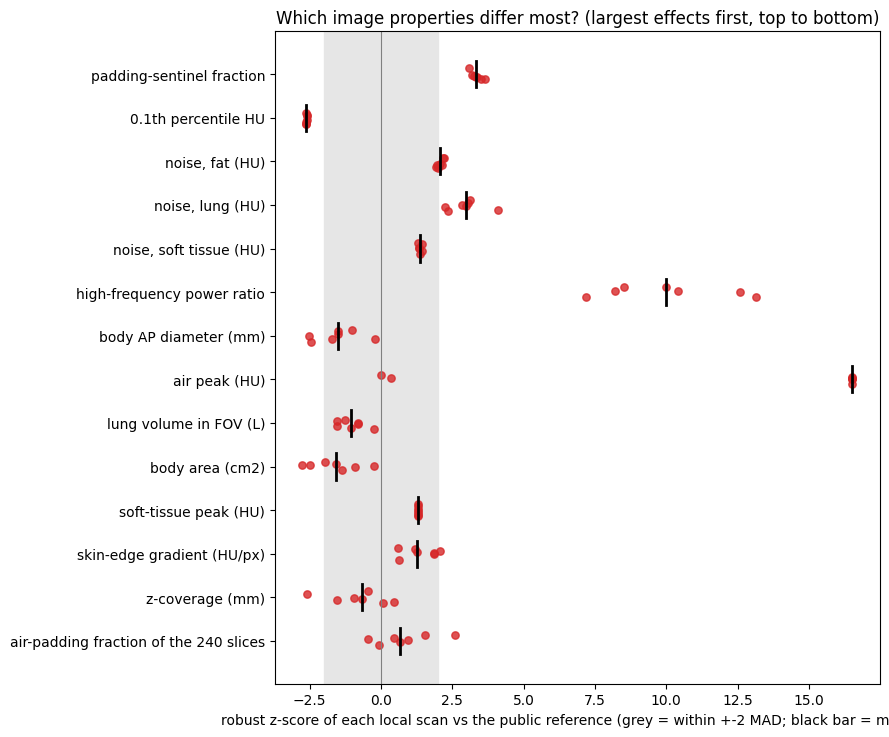

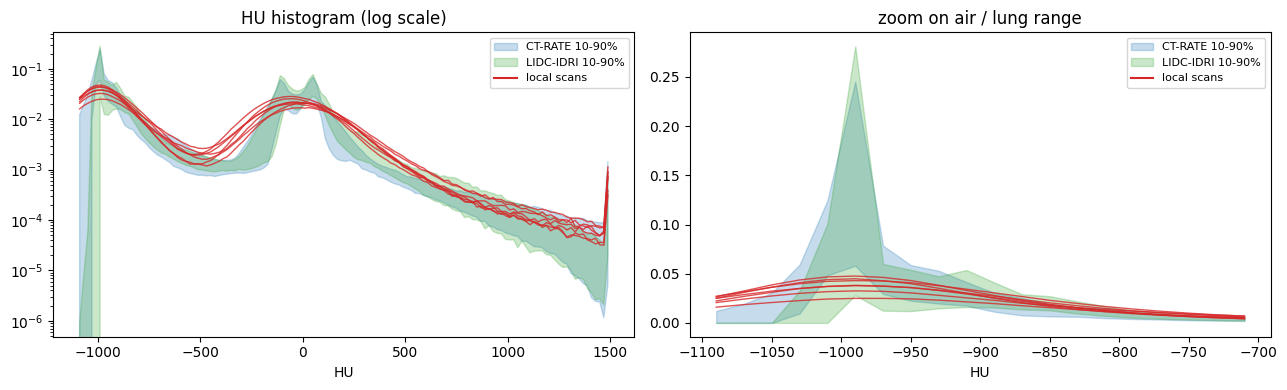

HU-histogram Wasserstein-1 distance, local vs all public: 43.6 HU | size-matched null median 28.5 (95th pct 69.3) | p = 0.261


In [13]:
STAT_COLS = [c for c in STATS_DF.columns if c in STAT_LABELS and STATS_DF[c].notna().sum() >= 6]
STAT_RES = {}
if CAN_ANALYSE:
    for rname, rmask in REFS.items():
        rows = []
        for c in STAT_COLS:
            a, b = STATS_DF.loc[LOCAL, c].to_numpy(float), STATS_DF.loc[rmask, c].to_numpy(float)
            if np.isnan(a).all() or np.isnan(b).all():
                continue
            def med_diff(q, rest): return abs(np.nanmedian(q) - np.nanmedian(rest))
            obs = abs(np.nanmedian(a) - np.nanmedian(b))
            null = np.empty(N_NULL)
            for i in range(N_NULL):
                q = RNG.choice(len(b), N_LOC, replace=False); rest = np.setdiff1d(np.arange(len(b)), q)
                null[i] = med_diff(b[q], b[rest])
            d = cliffs_delta(a, b)
            lo, hi = bootstrap_ci(lambda x, y: cliffs_delta(x, y), a[~np.isnan(a)], b[~np.isnan(b)], 300, RNG)
            rows.append(dict(stat=c, label=STAT_LABELS[c], local_median=np.nanmedian(a), ref_median=np.nanmedian(b), robust_z=float(np.nanmedian(robust_z(a, b))),
                             cliffs_delta=d, delta_ci_lo=lo, delta_ci_hi=hi, p=p_upper(obs, null)))
        T = pd.DataFrame(rows)
        if len(T):
            T["p_fdr"] = bh_fdr(T.p.to_numpy())
        STAT_RES[rname] = T.sort_values("cliffs_delta", key=lambda s: -s.abs()).reset_index(drop=True)
    main = STAT_RES["all public"] if "all public" in STAT_RES else next(iter(STAT_RES.values()))
    display(Markdown("#### Local scans vs all public reference scans (sorted by effect size)"))
    display(main[["label", "local_median", "ref_median", "robust_z", "cliffs_delta", "delta_ci_lo", "delta_ci_hi", "p", "p_fdr"]].round(3))
    for rname, T in STAT_RES.items():
        T.round(4).to_csv(OUTPUT_DIR / f"stats_vs_{rname.replace(' ', '_')}.csv", index=False)

    # forest plot: robust z of every local scan, per statistic, vs all-public
    ref_all = REFS.get("all public", next(iter(REFS.values())))
    order = list(main.stat)[:14][::-1]
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(order) + 1.6))
    for i, c in enumerate(order):
        z = robust_z(STATS_DF.loc[LOCAL, c].to_numpy(float), STATS_DF.loc[ref_all, c].to_numpy(float))
        ax.scatter(z, np.full(len(z), i) + RNG.uniform(-.15, .15, len(z)), c=COL["local"], s=28, alpha=.8)
        ax.plot([np.nanmedian(z)] * 2, [i - .3, i + .3], c="k", lw=2)
    ax.axvspan(-2, 2, color="0.9", zorder=0); ax.axvline(0, c="0.5", lw=.8)
    ax.set_yticks(range(len(order))); ax.set_yticklabels([STAT_LABELS[c] for c in order]); ax.set_xlabel("robust z-score of each local scan vs the public reference (grey = within +-2 MAD; black bar = median)")
    ax.set_title("Which image properties differ most? (largest effects first, top to bottom)"); savefig("stats_forest.png"); plt.show()

    # HU histogram overlay
    xs = np.arange(-1090, 1500, 20)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for a_, (lo, hi, ttl) in zip(ax, ((-1100, 1500, "HU histogram (log scale)"), (-1100, -700, "zoom on air / lung range"))):
        m = (xs >= lo) & (xs <= hi)
        for coh, lab_ in (("ctrate", "CT-RATE"), ("lidc", "LIDC-IDRI")):
            hh = HIST_M[(META_DF.cohort == coh).to_numpy() & PRIM]
            if len(hh) >= 3:
                a_.fill_between(xs[m], np.percentile(hh, 10, axis=0)[m], np.percentile(hh, 90, axis=0)[m], alpha=.25, color=COL[coh], label=f"{lab_} 10-90%")
        for h_ in HIST_M[LOCAL]:
            a_.plot(xs[m], h_[m], c=COL["local"], lw=1, alpha=.8)
        a_.plot([], [], c=COL["local"], label="local scans"); a_.set_yscale("log" if hi > 0 else "linear"); a_.set_title(ttl); a_.set_xlabel("HU"); a_.legend(fontsize=8)
    savefig("hu_histograms.png"); plt.show()
    cdf = lambda h: np.cumsum(h, axis=1)
    w1 = lambda a, b: np.abs(cdf(a).mean(0) - cdf(b).mean(0)).sum() * 20.0
    if len(REFS):
        rm = REFS.get("all public")
        obs = w1(HIST_M[LOCAL], HIST_M[rm]); null = size_matched_null(lambda q, r: w1(q, r), HIST_M[rm], N_LOC, min(N_NULL, 1000), RNG)
        print(f"HU-histogram Wasserstein-1 distance, local vs all public: {obs:.1f} HU | size-matched null median {np.median(null):.1f} (95th pct {np.percentile(null, 95):.1f}) | p = {p_upper(obs, null):.3f}")
        STAT_RES["hist_w1"] = dict(obs=obs, null_median=float(np.median(null)), null_p95=float(np.percentile(null, 95)), p=p_upper(obs, null))

## 10. Layer B results: learned features
For each feature space and each reference set: local novelty vs its size-matched null, energy distance, Fréchet distance (few dimensions), and a cross-validated domain classifier. Then the maps, the nearest public neighbours of every local scan, and the yardsticks.

In [14]:
SPACES = {k: v for k, v in EMB.items() if k in SPACE_OF}
SP_RES = []
Zs = {}          # (space, ref name) -> (Z for all rows from a space fitted on that reference, dims)
LOO = {}         # (space, ref name) -> out-of-sample novelty of every reference scan
if CAN_ANALYSE:
    for sp, X in SPACES.items():
        for rname, rmask in REFS.items():
            Xr, Xl = X[rmask], X[LOCAL]
            Z, k = make_space(X, rmask, PCA_DIMS); Zs[(sp, rname)] = (Z, k)
            stat_fns = {"novelty": lambda q, r: float(novelty(q, r, KNN_K).mean()), "energy": energy_distance}
            if N_LOC >= 4:
                stat_fns["frechet"] = lambda q, r: frechet_distance(q[:, :min(5, q.shape[1])], r[:, :min(5, r.shape[1])])
            obs, nul = matched_tests(Xr, Xl, PCA_DIMS, N_NULL, RNG, stat_fns)
            loo = loo_novelty(Xr, PCA_DIMS, KNN_K); LOO[(sp, rname)] = loo
            proj, _k = fit_space(Xr, PCA_DIMS)
            nov_scan = novelty(proj(Xl), proj(Xr), KNN_K)                 # every local scan vs the full reference
            auc, auc_p = domain_classifier_auc(Xr, Xl, PCA_DIMS, RNG, n_perm=100)
            SP_RES.append(dict(space=SPACE_OF[sp], _space=sp, reference=rname, n_ref=int(rmask.sum()), dims=k, novelty_local=obs["novelty"], novelty_null_median=float(np.median(nul["novelty"])),
                               novelty_ratio=obs["novelty"] / float(np.median(nul["novelty"])), novelty_p=p_upper(obs["novelty"], nul["novelty"]),
                               local_scans_above_ref_p95=int(np.sum(nov_scan > np.percentile(loo, 95))), median_scan_percentile=float(100 * np.mean([np.mean(loo < v) for v in nov_scan])),
                               energy_dist=obs["energy"], energy_ratio=(obs["energy"] / float(np.median(nul["energy"])) if np.median(nul["energy"]) > 0 else np.nan), energy_p=p_upper(obs["energy"], nul["energy"]),
                               frechet=obs.get("frechet", np.nan), frechet_p=p_upper(obs["frechet"], nul["frechet"]) if "frechet" in obs else np.nan, classifier_auc=auc, classifier_p=auc_p))
    SPR = pd.DataFrame(SP_RES)
    display(Markdown("#### Novelty / distribution distance / classifier, local vs reference (size-matched, out-of-sample nulls)"))
    display(SPR.drop(columns="_space").round(3))
    SPR.drop(columns="_space").round(4).to_csv(OUTPUT_DIR / "embedding_tests.csv", index=False)

#### Novelty / distribution distance / classifier, local vs reference (size-matched, out-of-sample nulls)

,space,reference,n_ref,dims,novelty_local,novelty_null_median,novelty_ratio,novelty_p,local_scans_above_ref_p95,median_scan_percentile,energy_dist,energy_ratio,energy_p,frechet,frechet_p,classifier_auc,classifier_p
0,CT-CLIP latent (512),all public,82,10,3.003,2.411,1.246,0.000,1,85.540,0.468,NaN,0.025,2.905,0.096,0.815,0.030
1,CT-CLIP latent (512),CT-RATE,48,10,3.050,2.546,1.198,0.018,1,78.571,0.455,NaN,0.039,3.455,0.050,0.827,0.010
2,CT-CLIP latent (512),LIDC-IDRI,34,10,3.246,2.829,1.147,0.007,2,84.034,0.560,NaN,0.011,2.845,0.114,0.866,0.030
3,CT-CLIP latent (512),LIDC Toshiba,10,8,1.247,1.267,0.984,0.688,3,81.429,-0.155,NaN,0.164,1.061,0.225,0.600,0.356
4,CT-CLIP encoder tokens (512),all public,82,10,2.491,2.108,1.182,0.082,1,67.596,0.424,NaN,0.024,5.109,0.008,0.697,0.089
5,CT-CLIP encoder tokens (512),CT-RATE,48,10,4.420,2.342,1.887,0.000,3,90.476,2.914,NaN,0.000,17.402,0.000,0.935,0.010
6,CT-CLIP encoder tokens (512),LIDC-IDRI,34,10,3.142,2.558,1.228,0.041,2,71.429,0.423,NaN,0.037,4.151,0.058,0.916,0.020
7,CT-CLIP encoder tokens (512),LIDC Toshiba,10,8,2.253,1.627,1.385,0.209,7,100.000,0.509,NaN,0.069,4.092,0.121,0.971,0.010
8,DALE-CT-0 (1024),all public,82,10,2.433,1.710,1.423,0.000,4,84.843,1.771,NaN,0.000,7.318,0.000,0.979,0.010
9,DALE-CT-0 (1024),CT-RATE,48,10,2.501,1.860,1.345,0.006,0,83.036,1.488,NaN,0.000,6.213,0.001,0.976,0.010


In [15]:
# ---- nearest public neighbours of every local scan
NN_ROWS = []
if CAN_ANALYSE:
    rname = "all public" if "all public" in REFS else next(iter(REFS))
    rmask = REFS[rname]
    for sp in SPACES:
        Z, k = Zs[(sp, rname)]
        D = cdist(Z[LOCAL], Z[rmask]); ref_ids = IDS[rmask]
        for i, lid in enumerate(IDS[LOCAL]):
            for j in np.argsort(D[i])[:3]:
                r = META_DF.loc[ref_ids[j]]
                NN_ROWS.append(dict(space=SPACE_OF[sp], local=lid, neighbour=ref_ids[j], distance=round(float(D[i, j]), 2), cohort=r.cohort, vendor=r.vendor, kernel=r.kernel, z_spacing=r.z_spacing))
    NN = pd.DataFrame(NN_ROWS)
    comp = NN.groupby(["space", "cohort", "vendor"]).size().unstack(["cohort", "vendor"], fill_value=0)
    display(Markdown("#### Who do the local scans resemble? (3 nearest public neighbours per local scan, counted by cohort and vendor)"))
    display(comp)
    NN.to_csv(OUTPUT_DIR / "nearest_public_neighbours.csv", index=False)

#### Who do the local scans resemble? (3 nearest public neighbours per local scan, counted by cohort and vendor)

cohort                       ctrate                 lidc                  \
vendor                         PNMS Philips Siemens   GE Philips Siemens   
space                                                                      
CT-CLIP encoder tokens (512)      2       1       5    6       3       2   
CT-CLIP latent (512)              3       5       6    2       0       3   
CT-FM (512)                       2       0       6    6       0       0   
DALE-CT-0 (1024)                  0       0       5    5       2       9   

cohort                                
vendor                       Toshiba  
space                                 
CT-CLIP encoder tokens (512)       2  
CT-CLIP latent (512)               2  
CT-FM (512)                        7  
DALE-CT-0 (1024)                   0

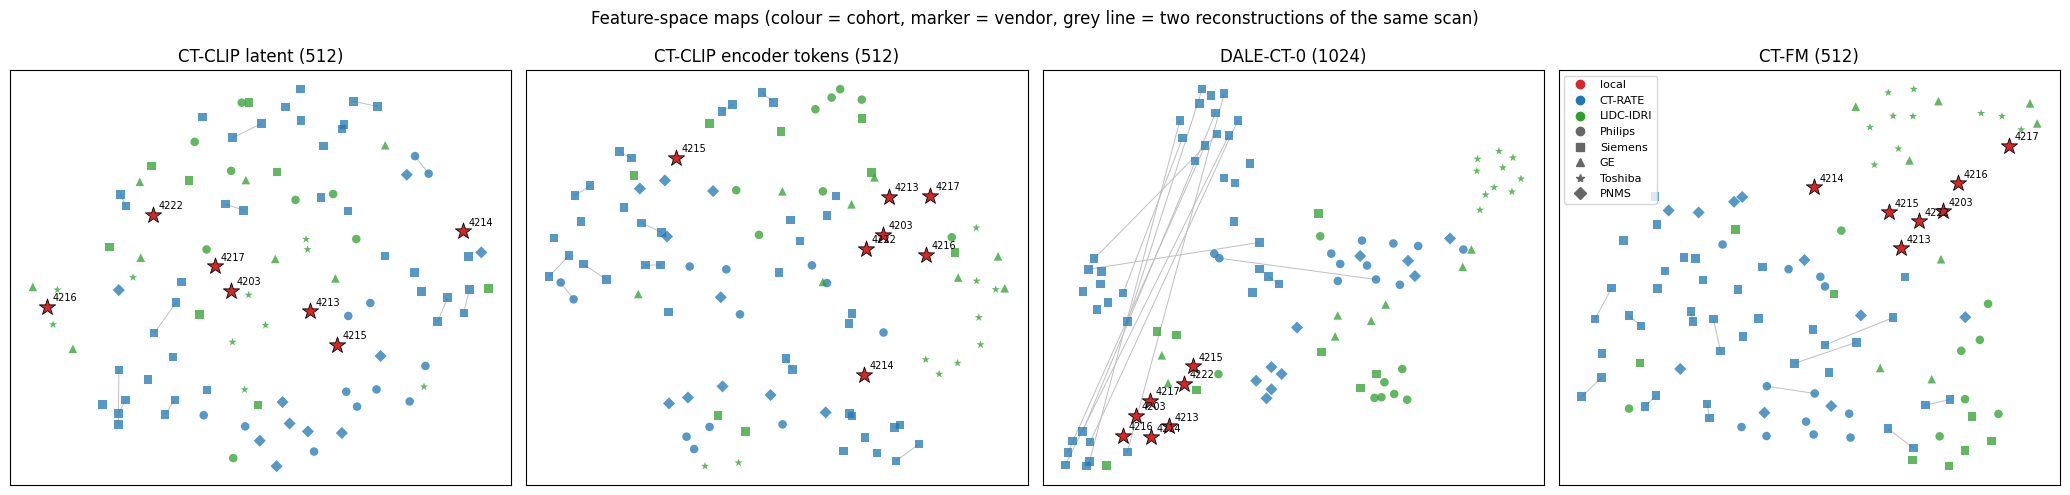

In [16]:
# ---- 2-D maps: UMAP (or t-SNE) per feature space; lines join two reconstructions of the same scan
def embed_2d(Z):
    n = len(Z)
    try:
        import umap
        return umap.UMAP(n_neighbors=int(max(4, min(12, n - 2))), min_dist=0.3, random_state=0).fit_transform(Z)
    except Exception:
        from sklearn.manifold import TSNE
        return TSNE(n_components=2, perplexity=max(2, min(15, (n - 1) // 3)), random_state=0, init="pca").fit_transform(Z)

MARK = {"Philips": "o", "Siemens": "s", "GE": "^", "Toshiba": "*", "PNMS": "D"}
if CAN_ANALYSE:
    fig, axes = plt.subplots(1, len(SPACES), figsize=(5.2 * len(SPACES), 5))
    axes = np.atleast_1d(axes)
    for ax, sp in zip(axes, SPACES):
        Zfull, _ = make_space(SPACES[sp], REFS.get("all public", next(iter(REFS.values()))), max(PCA_DIMS, 8))
        Z2 = embed_2d(Zfull)
        for pid, g in META_DF[META_DF.pair_id.notna()].groupby("pair_id"):
            ii = [list(IDS).index(i) for i in g.index]
            if len(ii) == 2:
                ax.plot(Z2[ii, 0], Z2[ii, 1], c="0.75", lw=.7, zorder=1)
        for coh in ("ctrate", "lidc", "extra", "local"):
            for v, mk in MARK.items():
                m = (META_DF.cohort == coh).to_numpy() & (META_DF.vendor == v).to_numpy()
                if m.any():
                    ax.scatter(Z2[m, 0], Z2[m, 1], c=COL[coh], marker=mk, s=(150 if coh == "local" else 38), alpha=(1 if coh == "local" else .75), edgecolors="k" if coh == "local" else "none", linewidths=.6, zorder=3 if coh == "local" else 2)
        for i in np.where(LOCAL)[0]:
            ax.annotate(IDS[i].replace("local_", ""), Z2[i], fontsize=7, xytext=(4, 4), textcoords="offset points")
        ax.set_title(SPACE_OF[sp]); ax.set_xticks([]); ax.set_yticks([])
    h = [plt.Line2D([], [], marker="o", ls="", c=COL[c], label=n) for c, n in (("local", "local"), ("ctrate", "CT-RATE"), ("lidc", "LIDC-IDRI"))] + [plt.Line2D([], [], marker=m, ls="", c="0.4", label=v) for v, m in MARK.items()]
    axes[-1].legend(handles=h, fontsize=8, loc="best")
    fig.suptitle("Feature-space maps (colour = cohort, marker = vendor, grey line = two reconstructions of the same scan)"); savefig("feature_maps.png"); plt.show()

### Yardsticks: how big is the local gap compared with gaps we understand?
In every feature space (fitted on CT-RATE only, so the yardsticks are clean):
* **same scan, different kernel**: distance between two reconstructions of one acquisition;
* **patient to patient**: distance to the nearest *other* CT-RATE patient (ordinary variation);
* **leave-one-vendor-out** and **leave-one-kernel-out**: novelty of random 7-scan sets from one vendor/kernel when that vendor/kernel is removed from the reference (the "never seen this scanner" situation, which is also ours);
* **local**: novelty of our scans against the same reference.

space,CT-CLIP latent (512),CT-CLIP encoder tokens (512),DALE-CT-0 (1024),CT-FM (512)
patient_to_patient_NN,2.47,2.13,1.72,2.44
same_scan_other_kernel,0.69,0.78,3.75,1.59
n_pairs,12.00,12.00,12.00,12.00
leave-vendor-out: Philips,2.74,3.31,2.29,2.73
leave-vendor-out: Siemens,3.98,2.76,2.85,2.73
LOCAL vs CT-RATE,2.97,3.89,2.47,2.90


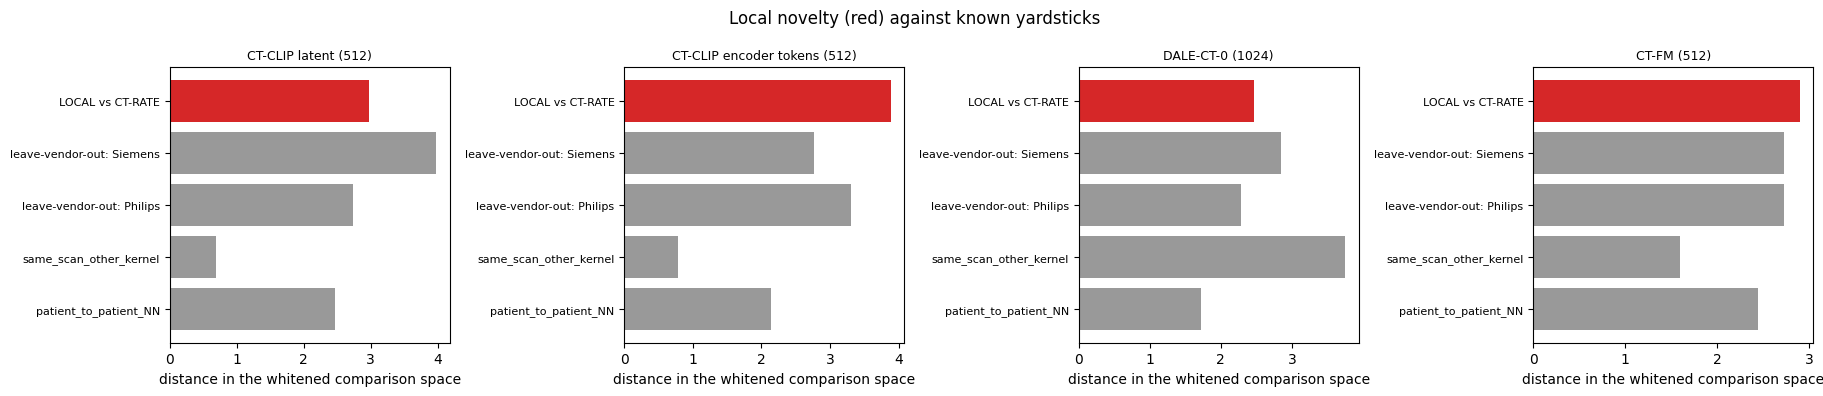

In [17]:
YARD = []
if CAN_ANALYSE and "CT-RATE" in REFS:
    cm = REFS["CT-RATE"]; sub = META_DF[cm]; ref_idx = np.where(cm)[0]
    for sp, X in SPACES.items():
        rec = dict(space=SPACE_OF[sp])
        rec["patient_to_patient_NN"] = float(np.median(LOO[(sp, "CT-RATE")]))
        pairs = []
        for pid, g in META_DF[META_DF.pair_id.notna() & (META_DF.cohort == "ctrate")].groupby("pair_id"):
            ii = [int(np.where(IDS == i)[0][0]) for i in g.index]
            if len(ii) == 2:
                rest = np.array([j for j in ref_idx if GROUPS[j] not in {GROUPS[ii[0]], GROUPS[ii[1]]}])
                proj, _k = fit_space(X[rest], PCA_DIMS)
                pairs.append(float(np.linalg.norm(proj(X[[ii[0]]]) - proj(X[[ii[1]]]))))
        rec["same_scan_other_kernel"] = float(np.median(pairs)) if pairs else np.nan; rec["n_pairs"] = len(pairs)
        for col, vals in (("vendor", ["Philips", "Siemens"]), ("kernel", [v for v in sub.kernel.value_counts().index if (sub.kernel == v).sum() >= max(N_LOC, 4)][:3])):
            for v in vals:
                hold = (META_DF[col] == v).to_numpy() & cm
                ref_rest = cm & ~hold
                if hold.sum() < max(N_LOC, 3) or ref_rest.sum() < 8:
                    continue
                proj, _k = fit_space(X[ref_rest], PCA_DIMS); Zrr = proj(X[ref_rest]); hidx = np.where(hold)[0]
                vals_ = [novelty(proj(X[RNG.choice(hidx, min(N_LOC, len(hidx)), replace=False)]), Zrr, KNN_K).mean() for _ in range(200)]
                rec[f"leave-{col}-out: {v}"] = float(np.median(vals_))
        proj, _k = fit_space(X[cm], PCA_DIMS)
        rec["LOCAL vs CT-RATE"] = float(np.median(novelty(proj(X[LOCAL]), proj(X[cm]), KNN_K)))
        YARD.append(rec)
    YARD = pd.DataFrame(YARD).set_index("space")
    display(YARD.round(2).T)
    YARD.round(4).to_csv(OUTPUT_DIR / "yardsticks.csv")
    cols = [c for c in YARD.columns if c not in ("n_pairs",)]
    fig, axes = plt.subplots(1, len(YARD), figsize=(4.6 * len(YARD), 4), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, (sp, r) in zip(axes, YARD.iterrows()):
        v = r[cols].dropna(); ax.barh(range(len(v)), v.values, color=["#d62728" if c.startswith("LOCAL") else "0.6" for c in v.index]); ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index, fontsize=8); ax.set_title(sp, fontsize=9)
        ax.set_xlabel("distance in the whitened comparison space")
    fig.suptitle("Local novelty (red) against known yardsticks"); savefig("yardsticks.png"); plt.show()

## 11. Layer C: does novelty predict CT-CLIP's error?
On the public CT-RATE scans we have labels, so we can ask whether scans that are *more novel* (within CT-RATE) are scored *worse* by CT-CLIP (binary cross-entropy of the 18 zero-shot probabilities). If novelty barely predicts error, a modest local novelty would not explain a large loss of accuracy; if it predicts error strongly, the local scans' novelty gives an expected penalty.

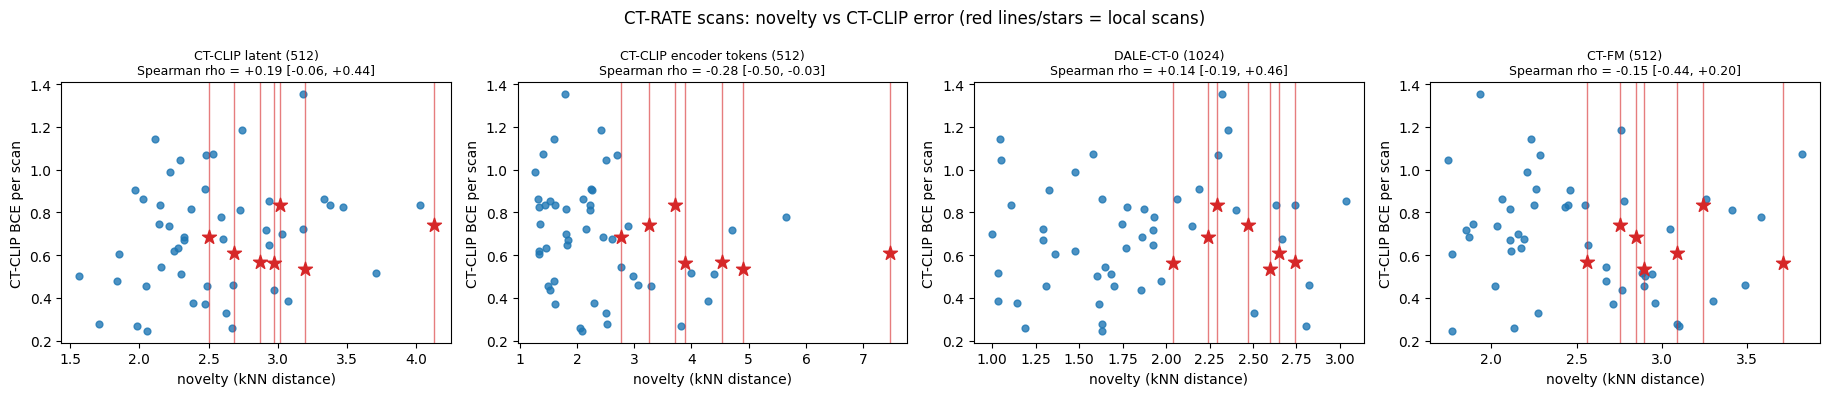

,space,n,spearman_rho,ci_lo,ci_hi
0,CT-CLIP latent (512),48,0.189,-0.058,0.436
1,CT-CLIP encoder tokens (512),48,-0.279,-0.500,-0.032
2,DALE-CT-0 (1024),48,0.142,-0.191,0.465
3,CT-FM (512),48,-0.153,-0.444,0.199


In [18]:
LINK = None
if CAN_ANALYSE and "CT-RATE" in REFS and any(v is not None for v in PROBS.values()):
    cm = REFS["CT-RATE"]; names = {it["id"]: it.get("name") for it in ITEMS}
    bce, ok = {}, []
    for i in IDS[cm]:
        n = names.get(i)
        if n in ct_labels.index and PROBS.get(i) is not None:
            y = ct_labels.loc[n, PATHOLOGIES].to_numpy(float); p = np.clip(PROBS[i].astype(float), 1e-4, 1 - 1e-4)
            bce[i] = float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))); ok.append(i)
    if len(ok) >= 12:
        rows = []
        fig, axes = plt.subplots(1, len(SPACES), figsize=(4.6 * len(SPACES), 4)); axes = np.atleast_1d(axes)
        # local labels (optional)
        loc_bce = {}
        if Path(LABELS_CSV).exists():
            lab = pd.read_csv(LABELS_CSV); lab["key"] = lab.ct_id.map(case_key); lab = lab.set_index("key")
            for i in IDS[LOCAL]:
                kk = case_key(i.replace("local_", ""))
                if kk in lab.index and PROBS.get(i) is not None and all(p in lab.columns for p in PATHOLOGIES):
                    p = np.clip(PROBS[i].astype(float), 1e-4, 1 - 1e-4); y = lab.loc[kk, PATHOLOGIES].to_numpy(float)
                    loc_bce[i] = float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
        for ax, sp in zip(axes, SPACES):
            nov = dict(zip(IDS[cm], LOO[(sp, "CT-RATE")]))
            x = np.array([nov[i] for i in ok]); yv = np.array([bce[i] for i in ok])
            rho = sps.spearmanr(x, yv)[0]
            boots = [sps.spearmanr(x[j], yv[j])[0] for j in (RNG.integers(0, len(x), len(x)) for _ in range(300))]
            lo, hi = np.nanpercentile(boots, [2.5, 97.5])
            rows.append(dict(space=SPACE_OF[sp], n=len(ok), spearman_rho=rho, ci_lo=lo, ci_hi=hi))
            ax.scatter(x, yv, c=COL["ctrate"], s=24, alpha=.8)
            proj, _k = fit_space(SPACES[sp][cm], PCA_DIMS); nl = novelty(proj(SPACES[sp][LOCAL]), proj(SPACES[sp][cm]), KNN_K)
            for v_, i in zip(nl, IDS[LOCAL]):
                ax.axvline(v_, c=COL["local"], lw=1, alpha=.6)
                if i in loc_bce:
                    ax.scatter([v_], [loc_bce[i]], c=COL["local"], marker="*", s=110, zorder=4)
            ax.set_xlabel("novelty (kNN distance)"); ax.set_ylabel("CT-CLIP BCE per scan"); ax.set_title(f"{SPACE_OF[sp]}\nSpearman rho = {rho:+.2f} [{lo:+.2f}, {hi:+.2f}]", fontsize=9)
        fig.suptitle("CT-RATE scans: novelty vs CT-CLIP error (red lines/stars = local scans)"); savefig("novelty_vs_error.png"); plt.show()
        LINK = pd.DataFrame(rows); display(LINK.round(3)); LINK.round(4).to_csv(OUTPUT_DIR / "novelty_vs_error.csv", index=False)
    else:
        print("too few CT-RATE scans with zero-shot probabilities for the performance link")
else:
    print("performance link skipped (needs CT-RATE scans with CT-CLIP probabilities)")

## 12. Controls: how big a change can we detect, and where do our scans fall?
A few CT-RATE scans (kept on disk for this purpose) are **degraded by known amounts**, and their novelty against the *remaining* reference is measured. This calibrates the scale: "local novelty is about as large as adding X HU of noise / Y voxels of blur". Degradations are applied to the model-input tensor: white noise, Gaussian in-plane blur (a softer kernel), an HU offset (calibration drift), and 2x slice averaging (thicker slices).

controls: valid_1016_b_1
controls: valid_1065_a_2
controls: valid_1082_b_2
controls: valid_1114_a_1
controls: valid_1222_a_2
controls: valid_1279_a_2


#### Novelty in units of the typical patient-to-patient gap (1.0 = an ordinary CT-RATE scan; local scans in the last row)

space,CT-CLIP encoder tokens (512),CT-CLIP latent (512),CT-FM (512),DALE-CT-0 (1024)
perturbation,,,,
none,1.04,0.85,0.98,0.89
noise 10,1.01,0.86,0.97,1.01
noise 25,0.99,0.88,1.00,1.08
noise 50,0.97,0.97,1.03,1.31
blur 0.6,1.07,0.91,0.98,1.08
blur 1.2,1.29,0.92,0.98,1.43
shift 30,1.04,0.85,0.96,0.88
shift -30,1.06,0.96,0.98,0.91
thick 2,1.06,0.91,0.98,1.06


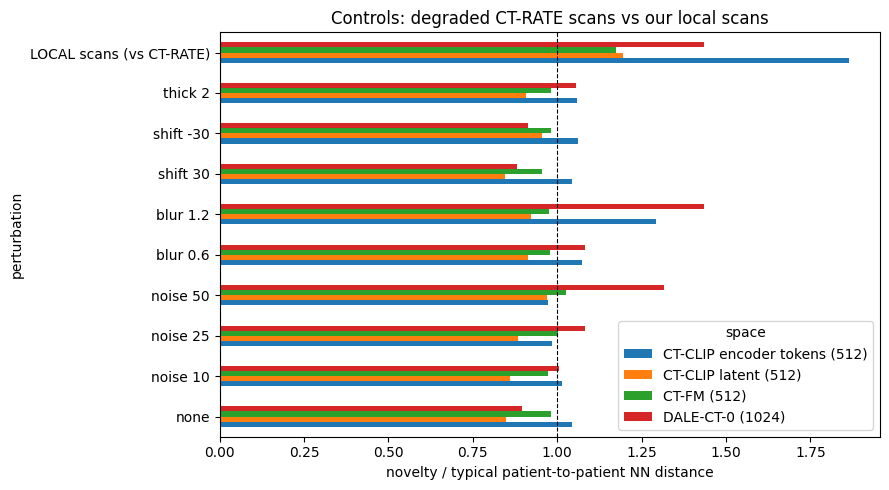

In [19]:
CTRL = None
def perturb(t, kind, level):
    x = t.clone(); valid = (x[0].amax(dim=(1, 2)) > -0.99)
    if kind == "noise":
        x[0, valid] += torch.randn_like(x[0, valid]) * (level / 1000.0)
    elif kind == "blur":
        r = int(np.ceil(3 * level)); g = torch.exp(-0.5 * (torch.arange(-r, r + 1).float() / level) ** 2); g /= g.sum()
        y = x[0, valid][:, None]
        y = F.conv2d(F.pad(y, (r, r, 0, 0), mode="replicate"), g.view(1, 1, 1, -1)); y = F.conv2d(F.pad(y, (0, 0, r, r), mode="replicate"), g.view(1, 1, -1, 1)); x[0, valid] = y[:, 0]
    elif kind == "shift":
        x[0, valid] += level / 1000.0
    elif kind == "thick":
        idx = torch.nonzero(valid).flatten(); v = x[0, idx]
        n = (len(idx) // level) * level
        if n:
            x[0, idx[:n]] = v[:n].reshape(-1, level, *v.shape[1:]).mean(1, keepdim=True).expand(-1, level, -1, -1).reshape(n, *v.shape[1:])
    return x.clamp_(-1, 1)

PERTURBATIONS = [("noise", 10), ("noise", 25), ("noise", 50), ("blur", 0.6), ("blur", 1.2), ("shift", 30), ("shift", -30), ("thick", 2)]
if RUN_CONTROLS and CAN_ANALYSE and "CT-RATE" in REFS:
    ctl_items = [it for it in ITEMS if it.get("control") and it["id"] in set(IDS)]
    if len(ctl_items) >= 2:
        ctl_ids = [it["id"] for it in ctl_items]
        rows = []
        E0 = {}    # (id, perturbation) -> {space: vector}
        for it in ctl_items:
            vB, spB, meta, _ = obtain_volume(it); t0 = preprocess_volume(vB, spB); del vB
            for kind, lvl in [(None, 0)] + PERTURBATIONS:
                t = t0 if kind is None else perturb(t0, kind, lvl)
                emb = {}
                for e in EXT.values():
                    emb.update(e.embed(t))
                E0[(it["id"], kind, lvl)] = emb
            print("controls:", it["id"])
        ref_mask = REFS["CT-RATE"] & ~np.isin(IDS, ctl_ids)
        for sp, X in SPACES.items():
            mu, sd = X[ref_mask].mean(0), X[ref_mask].std(0) + 1e-8
            k = int(max(2, min(PCA_DIMS, ref_mask.sum() - 2)))
            pca = PCA(n_components=k, whiten=True, random_state=0).fit((X[ref_mask] - mu) / sd)
            proj = lambda v: pca.transform(((np.asarray(v, float) - mu) / sd)[None])
            Zref = pca.transform((X[ref_mask] - mu) / sd)
            loo_med = float(np.median(loo_novelty(X[ref_mask], PCA_DIMS, KNN_K)))
            loc_nov = float(np.median(novelty(pca.transform((X[LOCAL] - mu) / sd), Zref, KNN_K)))
            for kind, lvl in [(None, 0)] + PERTURBATIONS:
                vals = [float(novelty(proj(E0[(i, kind, lvl)][sp]), Zref, KNN_K)[0]) for i in ctl_ids]
                rows.append(dict(space=SPACE_OF[sp], perturbation=("none" if kind is None else f"{kind} {lvl}"), novelty_median=float(np.median(vals)), x_of_typical_patient_gap=float(np.median(vals)) / loo_med,
                                 local_novelty=loc_nov, local_x_of_typical_patient_gap=loc_nov / loo_med))
        CTRL = pd.DataFrame(rows)
        piv = CTRL.pivot(index="perturbation", columns="space", values="x_of_typical_patient_gap").reindex(["none"] + [f"{k} {l}" for k, l in PERTURBATIONS])
        loc_row = CTRL.groupby("space").local_x_of_typical_patient_gap.first()
        piv.loc["LOCAL scans (vs CT-RATE)"] = loc_row
        display(Markdown("#### Novelty in units of the typical patient-to-patient gap (1.0 = an ordinary CT-RATE scan; local scans in the last row)"))
        display(piv.round(2)); CTRL.round(4).to_csv(OUTPUT_DIR / "controls.csv", index=False)
        piv.plot.barh(figsize=(9, 5)); plt.axvline(1.0, c="k", lw=.8, ls="--"); plt.xlabel("novelty / typical patient-to-patient NN distance"); plt.title("Controls: degraded CT-RATE scans vs our local scans"); savefig("controls.png"); plt.show()
    else:
        print("controls skipped: fewer than 2 control scans available")
else:
    print("controls not run (set RUN_CONTROLS = '1', needs CT-RATE scans)")

## 13. Summary

In [20]:
SUMMARY = {"n_local": N_LOC, "reference_sizes": {k: int(v.sum()) for k, v in REFS.items()}, "device": DEV, "dry_run": DRY_RUN_RANDOM_WEIGHTS, "created": dt.datetime.now().isoformat(timespec="seconds")}
lines = []
if CAN_ANALYSE:
    main_ref = "all public" if "all public" in REFS else next(iter(REFS))
    sub = SPR[SPR.reference == main_ref]
    display(Markdown(f"### Evidence table (reference = {main_ref}, n = {REFS[main_ref].sum()}; local n = {N_LOC})"))
    tbl = sub[["space", "novelty_ratio", "novelty_p", "median_scan_percentile", "energy_ratio", "energy_p", "classifier_auc", "classifier_p"]].round(3)
    display(tbl)
    n_sig = int((sub.novelty_p < 0.05).sum()); n_sp = len(sub)
    lines.append(f"- **Feature spaces:** local scans are more novel than random same-size sets of public scans in {n_sig} of {n_sp} feature spaces (novelty p < 0.05). "
                 f"Median novelty ratio (local / null median) = {sub.novelty_ratio.median():.2f}; the typical local scan sits at percentile {sub.median_scan_percentile.median():.0f} of public-to-public novelty.")
    lines.append(f"- **Distribution tests:** energy distance p < 0.05 in {int((sub.energy_p < .05).sum())}/{n_sp} spaces; cross-validated domain-classifier AUC (local vs public) median {sub.classifier_auc.median():.2f} (0.5 = indistinguishable), "
                 f"significant in {int((sub.classifier_p < .05).sum())}/{n_sp} spaces.")
    if isinstance(YARD, pd.DataFrame) and len(YARD):
        vend = [c for c in YARD.columns if c.startswith("leave-vendor-out")]
        if vend:
            r = (YARD["LOCAL vs CT-RATE"] / YARD[vend].mean(axis=1))
            lines.append(f"- **Yardstick:** local novelty against CT-RATE is {r.median():.2f}x the novelty of an *unseen CT-RATE vendor* (leave-one-vendor-out) and "
                         f"{(YARD['LOCAL vs CT-RATE'] / YARD['patient_to_patient_NN']).median():.1f}x the ordinary patient-to-patient distance"
                         + (f"; two reconstructions of the same scan are {(YARD['same_scan_other_kernel'] / YARD['patient_to_patient_NN']).median():.2f}x the patient-to-patient distance." if YARD["same_scan_other_kernel"].notna().any() else "."))
    if "all public" in STAT_RES and len(STAT_RES["all public"]):
        m = STAT_RES["all public"]; big = m[(m.cliffs_delta.abs() >= 0.474) & (m.p_fdr < 0.1)]
        top = ", ".join(f"{r.label} (robust z {r.robust_z:+.1f})" for r in m.head(4).itertuples())
        lines.append(f"- **Image statistics:** {len(big)} of {len(m)} statistics show a large effect (|Cliff's delta| >= 0.47) that survives FDR correction. Largest differences: {top}.")
    if isinstance(LINK, pd.DataFrame) and len(LINK):
        lines.append(f"- **Does novelty matter for CT-CLIP?** Across {int(LINK.n.iloc[0])} CT-RATE scans, novelty vs CT-CLIP error has Spearman rho between {LINK.spearman_rho.min():+.2f} and {LINK.spearman_rho.max():+.2f} depending on the feature space "
                     f"(intervals are wide; rho near 0 would mean novelty predicts error poorly).")
    if isinstance(CTRL, pd.DataFrame) and len(CTRL):
        lines.append("- **Controls:** see the controls table: the last row (local) can be read against noise / blur / HU-shift / thick-slice degradations of CT-RATE scans.")
    lines.append(f"- **Caution:** {N_LOC} local scans from one scanner: p-values are coarse, effects are what to look at. Novelty measured with CT-CLIP and DALE-CT is relative to CT-RATE (their training data); CT-FM was not trained on CT-RATE, so agreement across all three is the strongest evidence.")
    display(Markdown("**Findings**\n\n" + "\n".join(lines)))
    SUMMARY["evidence"] = tbl.to_dict(orient="records"); SUMMARY["findings"] = lines
    (OUTPUT_DIR / "summary.md").write_text("# Domain-gap summary\n\n" + "\n".join(lines) + "\n\n" + tbl.to_markdown(index=False) + "\n", encoding="utf-8") if hasattr(tbl, "to_markdown") else None
(OUTPUT_DIR / "summary.json").write_text(json.dumps(SUMMARY, indent=1, default=float))
META_DF.join(STATS_DF).round(4).to_csv(OUTPUT_DIR / "all_scans_metadata_and_stats.csv")
print("outputs written to", OUTPUT_DIR)

### Evidence table (reference = all public, n = 82; local n = 7)

,space,novelty_ratio,novelty_p,median_scan_percentile,energy_ratio,energy_p,classifier_auc,classifier_p
0,CT-CLIP latent (512),1.246,0.000,85.540,NaN,0.025,0.815,0.030
4,CT-CLIP encoder tokens (512),1.182,0.082,67.596,NaN,0.024,0.697,0.089
8,DALE-CT-0 (1024),1.423,0.000,84.843,NaN,0.000,0.979,0.010
12,CT-FM (512),1.193,0.015,73.519,NaN,0.000,0.979,0.010


**Findings**

- **Feature spaces:** local scans are more novel than random same-size sets of public scans in 3 of 4 feature spaces (novelty p < 0.05). Median novelty ratio (local / null median) = 1.22; the typical local scan sits at percentile 79 of public-to-public novelty.
- **Distribution tests:** energy distance p < 0.05 in 4/4 spaces; cross-validated domain-classifier AUC (local vs public) median 0.90 (0.5 = indistinguishable), significant in 3/4 spaces.
- **Yardstick:** local novelty against CT-RATE is 1.01x the novelty of an *unseen CT-RATE vendor* (leave-one-vendor-out) and 1.3x the ordinary patient-to-patient distance; two reconstructions of the same scan are 0.51x the patient-to-patient distance.
- **Image statistics:** 10 of 20 statistics show a large effect (|Cliff's delta| >= 0.47) that survives FDR correction. Largest differences: padding-sentinel fraction (robust z +3.3), 0.1th percentile HU (robust z -2.6), noise, fat (HU) (robust z +2.1), noise, lung (HU) (robust z +3.0).
- **Does novelty matter for CT-CLIP?** Across 48 CT-RATE scans, novelty vs CT-CLIP error has Spearman rho between -0.28 and +0.19 depending on the feature space (intervals are wide; rho near 0 would mean novelty predicts error poorly).
- **Controls:** see the controls table: the last row (local) can be read against noise / blur / HU-shift / thick-slice degradations of CT-RATE scans.
- **Caution:** 7 local scans from one scanner: p-values are coarse, effects are what to look at. Novelty measured with CT-CLIP and DALE-CT is relative to CT-RATE (their training data); CT-FM was not trained on CT-RATE, so agreement across all three is the strongest evidence.

outputs written to /content/drive/MyDrive/NHRD - Local Sample/domain_gap_outputs
